# Most Streamed Spotify Songs 2023

- track_name: Numele melodiei
- artist(s)name: Numele artistului(ilor) melodiei
- artist_count: Numărul de artiști care contribuie la melodie
- released_year: Anul în care melodia a fost lansată
- released_month: Luna în care melodia a fost lansată
- released_day: Ziua lunii în care melodia a fost lansată
- in_spotify_playlists: Numărul de liste de redare Spotify în care melodia este inclusă
- streams: Numărul total de audiții pe Spotify
- in_apple_playlists: Numărul de liste de redare Apple Music în care melodia este inclusă
- in_apple_charts: Prezența și poziția melodiei în clasamentele Apple Music
- in_deezer_playlists: Numărul de liste de redare Deezer în care melodia este inclusă
- in_deezer_charts: Prezența și poziția melodiei în clasamentele Deezer
- in_shazam_charts: Prezența și poziția melodiei în clasamentele Shazam
- bpm: Bătăi pe minut, o măsură a tempoului melodiei
- key: Tonalitatea melodiei
- mode: Modul melodiei (major sau minor)
- danceability%: Procentaj care indică cât de potrivită este melodia pentru dans
- valence_%: Pozitivitatea conținutului muzical al melodiei
- energy_%: Nivelul de energie perceput al melodiei
- acousticness_%: Cantitatea de sunet acustic din melodie
- instrumentalness_%: Cantitatea de conținut instrumental din melodie
- liveness_%: Prezența elementelor de interpretare live
- speechiness_%: Cantitatea de cuvinte vorbite în melodie

Vechea variabila tinta:
- in_spotify_charts: Prezența și poziția melodiei în clasamentele Spotify - MODIFICAȚI coloana asta astfel încăt să fie 0 dacă nu e prezentă în topuri spotify, 1 dacă e prezentă dar nu în top5, 2 dacă e în top 5.

Am modificat variabila tinta si acum este:
- in_spotify_charts_target: 0 daca nu apare in topuri Spotify, 1 daca apare in topuri Spotify

#  I. Analiza exploratorie a datelor

## 1.Prezentarea cantitativa a datelor

In [1]:
import pandas as pd
import numpy as np
import sqlite3

import seaborn as sns 
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import sklearn.metrics as met
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import mean_absolute_percentage_error as mape
from sklearn import metrics
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

In [2]:
#citirea setului de date
cale_set_de_date = r'C:\temp\DateLaborator\Kaggle\Set11\spotify-2023.csv'
df = pd.read_csv (cale_set_de_date, encoding='latin-1')
#display(df)
#df.info()

In [3]:
#se verifica numarul de tabele
if isinstance(df, pd.DataFrame):
    print("setul de date are un singur tabel")
else:
    print(f"setul de date are {len(df)} tabele")

setul de date are un singur tabel


In [4]:
#verificare numar de inregistrari din setul de date
print(f"setul de date are {len(df)} inregistrari")

setul de date are 953 inregistrari


Avem un singur tabel, nu avem tabele multiple, deci nu avem chei de legatura intre ele.

### Analiza datelor lipsa

In [5]:
#pe coloane, numarul de valori lipsa, proportia de valori bune, proportia de valori lipsa
print("Pe coloane, numarul de inregistrari lipsa (proportia de date lipsa la nivel de coloana) ")
results = []
for c in df.columns:
    missing_cnt = df[df[c].isna()].shape[0]
    dict_row ={ "Nume coloana": c,
                "Nr. valori lipsa": str(missing_cnt),
                "Procent valori bune": round( 100*(1-missing_cnt/df.shape[0]),2),
                "Procent valori lipsa": round(100 * (missing_cnt /df.shape[0]), 2),
              }
    results.append(dict_row)
display(pd.DataFrame(results))

Pe coloane, numarul de inregistrari lipsa (proportia de date lipsa la nivel de coloana) 


,Nume coloana,Nr. valori lipsa,Procent valori bune,Procent valori lipsa
0,track_name,0,100.00,0.00
1,artist(s)_name,0,100.00,0.00
2,artist_count,0,100.00,0.00
3,released_year,0,100.00,0.00
4,released_month,0,100.00,0.00
5,released_day,0,100.00,0.00
6,in_spotify_playlists,0,100.00,0.00
7,in_spotify_charts,0,100.00,0.00
8,streams,0,100.00,0.00
9,in_apple_playlists,0,100.00,0.00


In [6]:
#pe linii, numarul de valori lipsa, proportia de valori bune, proportia de valori lipsa 
print("Pe linii, numarul de inregistari cu cel putin o valoare lipsa (proporita de inregistrari incomplete)")
results_rows = []
for index, row in df.iterrows():
    missing_cnt_row = row.isna().sum()
    if missing_cnt_row > 0:
        dict_row = {"Index linie": index,
                    "Nr. de valori lipsa": str(missing_cnt_row),
                    "Procent valori atribute complete": round(100 * (1 - missing_cnt_row / len(row)), 2),
                    "Procent valori atribute incomplete": round(100 * (missing_cnt_row / len(row)), 2)
                    }
        results_rows.append(dict_row)
display(pd.DataFrame(results_rows))

randuri_totale = len(df)
randuri_lipsa = df.isna().any(axis=1).sum()

proportia_completa = round(100 * (1 - randuri_lipsa / randuri_totale), 2)
proportia_incompleta = round(100 * (randuri_lipsa / randuri_totale), 2)

print("Proportia generala de inregistrari complete:", proportia_completa, "%")
print("Proportia generala de inregistrari incomplete:", proportia_incompleta, "%")

Pe linii, numarul de inregistari cu cel putin o valoare lipsa (proporita de inregistrari incomplete)


,Index linie,Nr. de valori lipsa,Procent valori atribute complete,Procent valori atribute incomplete
0,12,1,95.83,4.17
1,14,1,95.83,4.17
2,17,1,95.83,4.17
3,22,1,95.83,4.17
4,35,1,95.83,4.17
...,...,...,...,...
131,901,1,95.83,4.17
132,903,1,95.83,4.17
133,927,1,95.83,4.17
134,938,1,95.83,4.17


Proportia generala de inregistrari complete: 85.73 %
Proportia generala de inregistrari incomplete: 14.27 %


In [7]:
df_modificat = df.dropna(subset=['in_shazam_charts', 'key'])
display(df_modificat)

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
948,My Mind & Me,Selena Gomez,1,2022,11,3,953,0,91473363,61,...,144,A,Major,60,24,39,57,0,8,3
949,Bigger Than The Whole Sky,Taylor Swift,1,2022,10,21,1180,0,121871870,4,...,166,F#,Major,42,7,24,83,1,12,6
950,A Veces (feat. Feid),"Feid, Paulo Londra",2,2022,11,3,573,0,73513683,2,...,92,C#,Major,80,81,67,4,0,8,6
951,En La De Ella,"Feid, Sech, Jhayco",3,2022,10,20,1320,0,133895612,29,...,97,C#,Major,82,67,77,8,0,12,5


din 953 de inregistrari, am ramas cu 817, am eliminat aprox. 14% din setul de date initial,
pentru ca este un procent destul de mare si atributele sunt importante, in analiza as dori ca valorile lipsa din coloanele "in_shazam_charts" si "key" sa le inlocuiesc.

pentru coloana "in_shazam_charts" valorile lipsa vor fi inlocuite cu 0, iar 
pentru coloana "key" valorile lipsa vor fi inlocuite cu -1

In [8]:
#Inlocuire valori nule din coloana "in_shazam_charts" cu 0
df['in_shazam_charts'].fillna(0, inplace=True)

#Inlocuirea virgulei din interiorul valorilor cu un sir gol si convertirea in tipul int64
df['in_shazam_charts'] = df['in_shazam_charts'].replace(',', '', regex=True).astype('int64')

In [9]:
# Convertirea valorilor din coloana "key" in numere intregi
pitch_class = {'C': 0,
               'C#': 1,
               'D': 2,
               'D#': 3,
               'E': 4,
               'F': 5,
               'F#': 6,
               'G': 7,
               'G#': 8,
               'A': 9,
               'A#': 10,
               'B': 11
               }

df['key'] = df['key'].map(pitch_class)

#Inlocuire valori nule din coloana "key" cu -1
df['key'].fillna(-1, inplace=True)

# Convertirea la tipul int64
df['key'] = df['key'].astype('int64')

In [10]:
# Adaugare coloana "in_spotify_charts_target"
df['in_spotify_charts_target'] = df['in_spotify_charts'].apply(lambda x: 0 if x==0 else 1)

count_values = df['in_spotify_charts_target'].value_counts()
print(count_values)

in_spotify_charts_target
1    548
0    405
Name: count, dtype: int64


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   track_name                953 non-null    object
 1   artist(s)_name            953 non-null    object
 2   artist_count              953 non-null    int64 
 3   released_year             953 non-null    int64 
 4   released_month            953 non-null    int64 
 5   released_day              953 non-null    int64 
 6   in_spotify_playlists      953 non-null    int64 
 7   in_spotify_charts         953 non-null    int64 
 8   streams                   953 non-null    object
 9   in_apple_playlists        953 non-null    int64 
 10  in_apple_charts           953 non-null    int64 
 11  in_deezer_playlists       953 non-null    object
 12  in_deezer_charts          953 non-null    int64 
 13  in_shazam_charts          953 non-null    int64 
 14  bpm                       

## 2. Prezentarea calitativa a datelor

In [12]:
tipuri_de_atribute=df.dtypes
print("tipurile de atribute din dataframe sunt urmatoarele: ")
display(tipuri_de_atribute)

tipurile de atribute din dataframe sunt urmatoarele: 


track_name                  object
artist(s)_name              object
artist_count                 int64
released_year                int64
released_month               int64
released_day                 int64
in_spotify_playlists         int64
in_spotify_charts            int64
streams                     object
in_apple_playlists           int64
in_apple_charts              int64
in_deezer_playlists         object
in_deezer_charts             int64
in_shazam_charts             int64
bpm                          int64
key                          int64
mode                        object
danceability_%               int64
valence_%                    int64
energy_%                     int64
acousticness_%               int64
instrumentalness_%           int64
liveness_%                   int64
speechiness_%                int64
in_spotify_charts_target     int64
dtype: object

### Distributia valorilor - reprezentari grafice

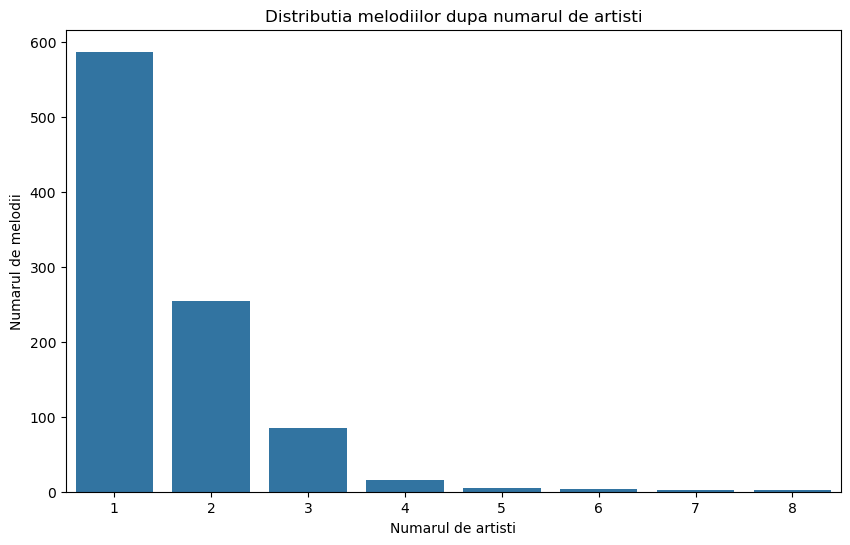

In [13]:
#distributia melodiilor in functie de numarul de artisti implicati in fiecare melodie

plt.figure(figsize=(10, 6))

#se utilizeaza seaborn
sns.countplot(x='artist_count', data=df)

#adauga etichete pentru cele doua axe si titlul
plt.xlabel('Numarul de artisti')
plt.ylabel('Numarul de melodii')
plt.title('Distributia melodiilor dupa numarul de artisti')

plt.show()

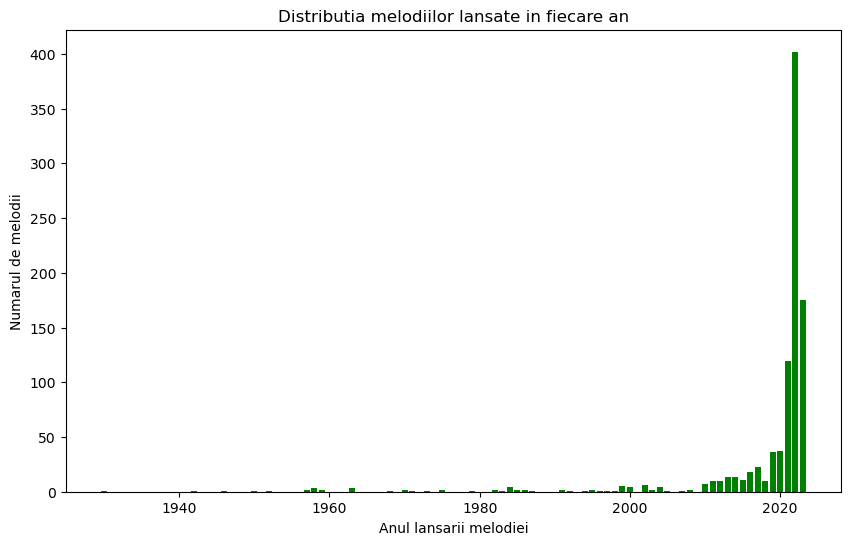

In [14]:
#distributia melodiilor in functie de anul lansarii

#numara pentru fiecare an cate melodii au fost lansate, apoi sorteaza crescator dupa ani
melodii_pe_an = df['released_year'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.bar(melodii_pe_an.index, melodii_pe_an.values, color='green')

plt.xlabel('Anul lansarii melodiei')
plt.ylabel('Numarul de melodii')
plt.title('Distributia melodiilor lansate in fiecare an')

plt.show()

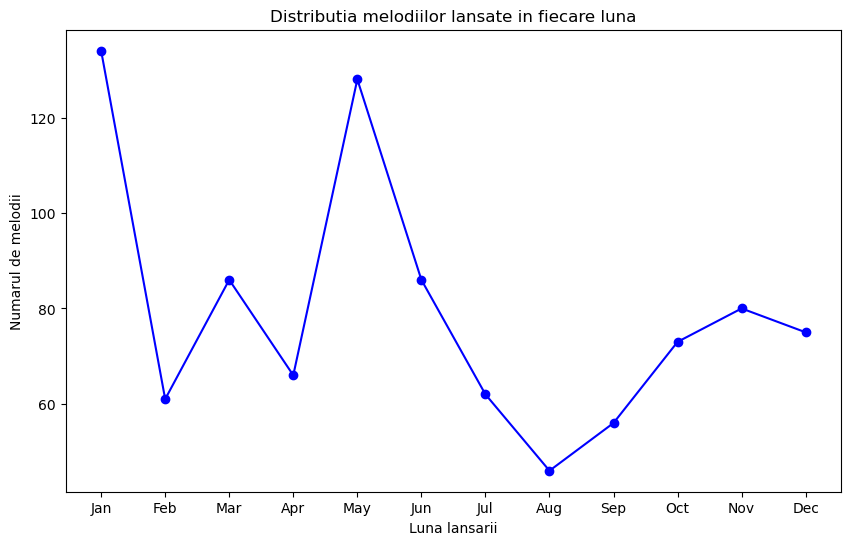

In [15]:
#distributia melodiilor in functie de luna lansarii

import calendar

plt.figure(figsize=(10, 6))

#se obtin abrevierile fiecarei lunii, folosind functia "calendar.month_abbr" din modulul "calendar"
abrevierea_lunii = [calendar.month_abbr[i] for i in range(1, 13)]

#numara cate melodii au fost lansate in fiecare luna
numar_melodii_pe_luna=df['released_month'].value_counts().sort_index()

plt.plot(abrevierea_lunii, numar_melodii_pe_luna.values, color='blue', marker='o', linestyle='solid')

plt.xlabel('Luna lansarii')
plt.ylabel('Numarul de melodii')
plt.title('Distributia melodiilor lansate in fiecare luna')
plt.show()

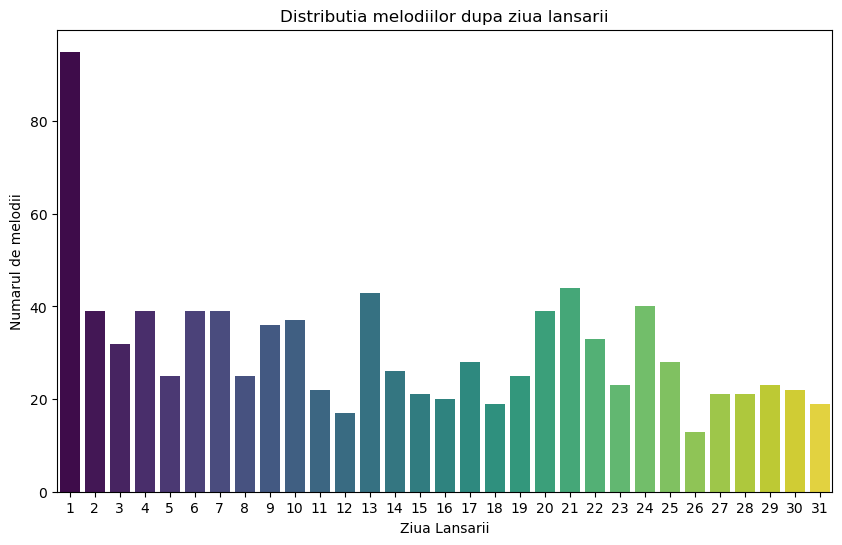

In [16]:
#distributia melodiilor in functie de ziua lansarii

plt.figure(figsize=(10, 6)) 

sns.countplot(x='released_day', data=df, palette='viridis', hue='released_day', legend=False)

plt.xlabel('Ziua Lansarii')
plt.ylabel('Numarul de melodii')
plt.title('Distributia melodiilor dupa ziua lansarii')

plt.show()

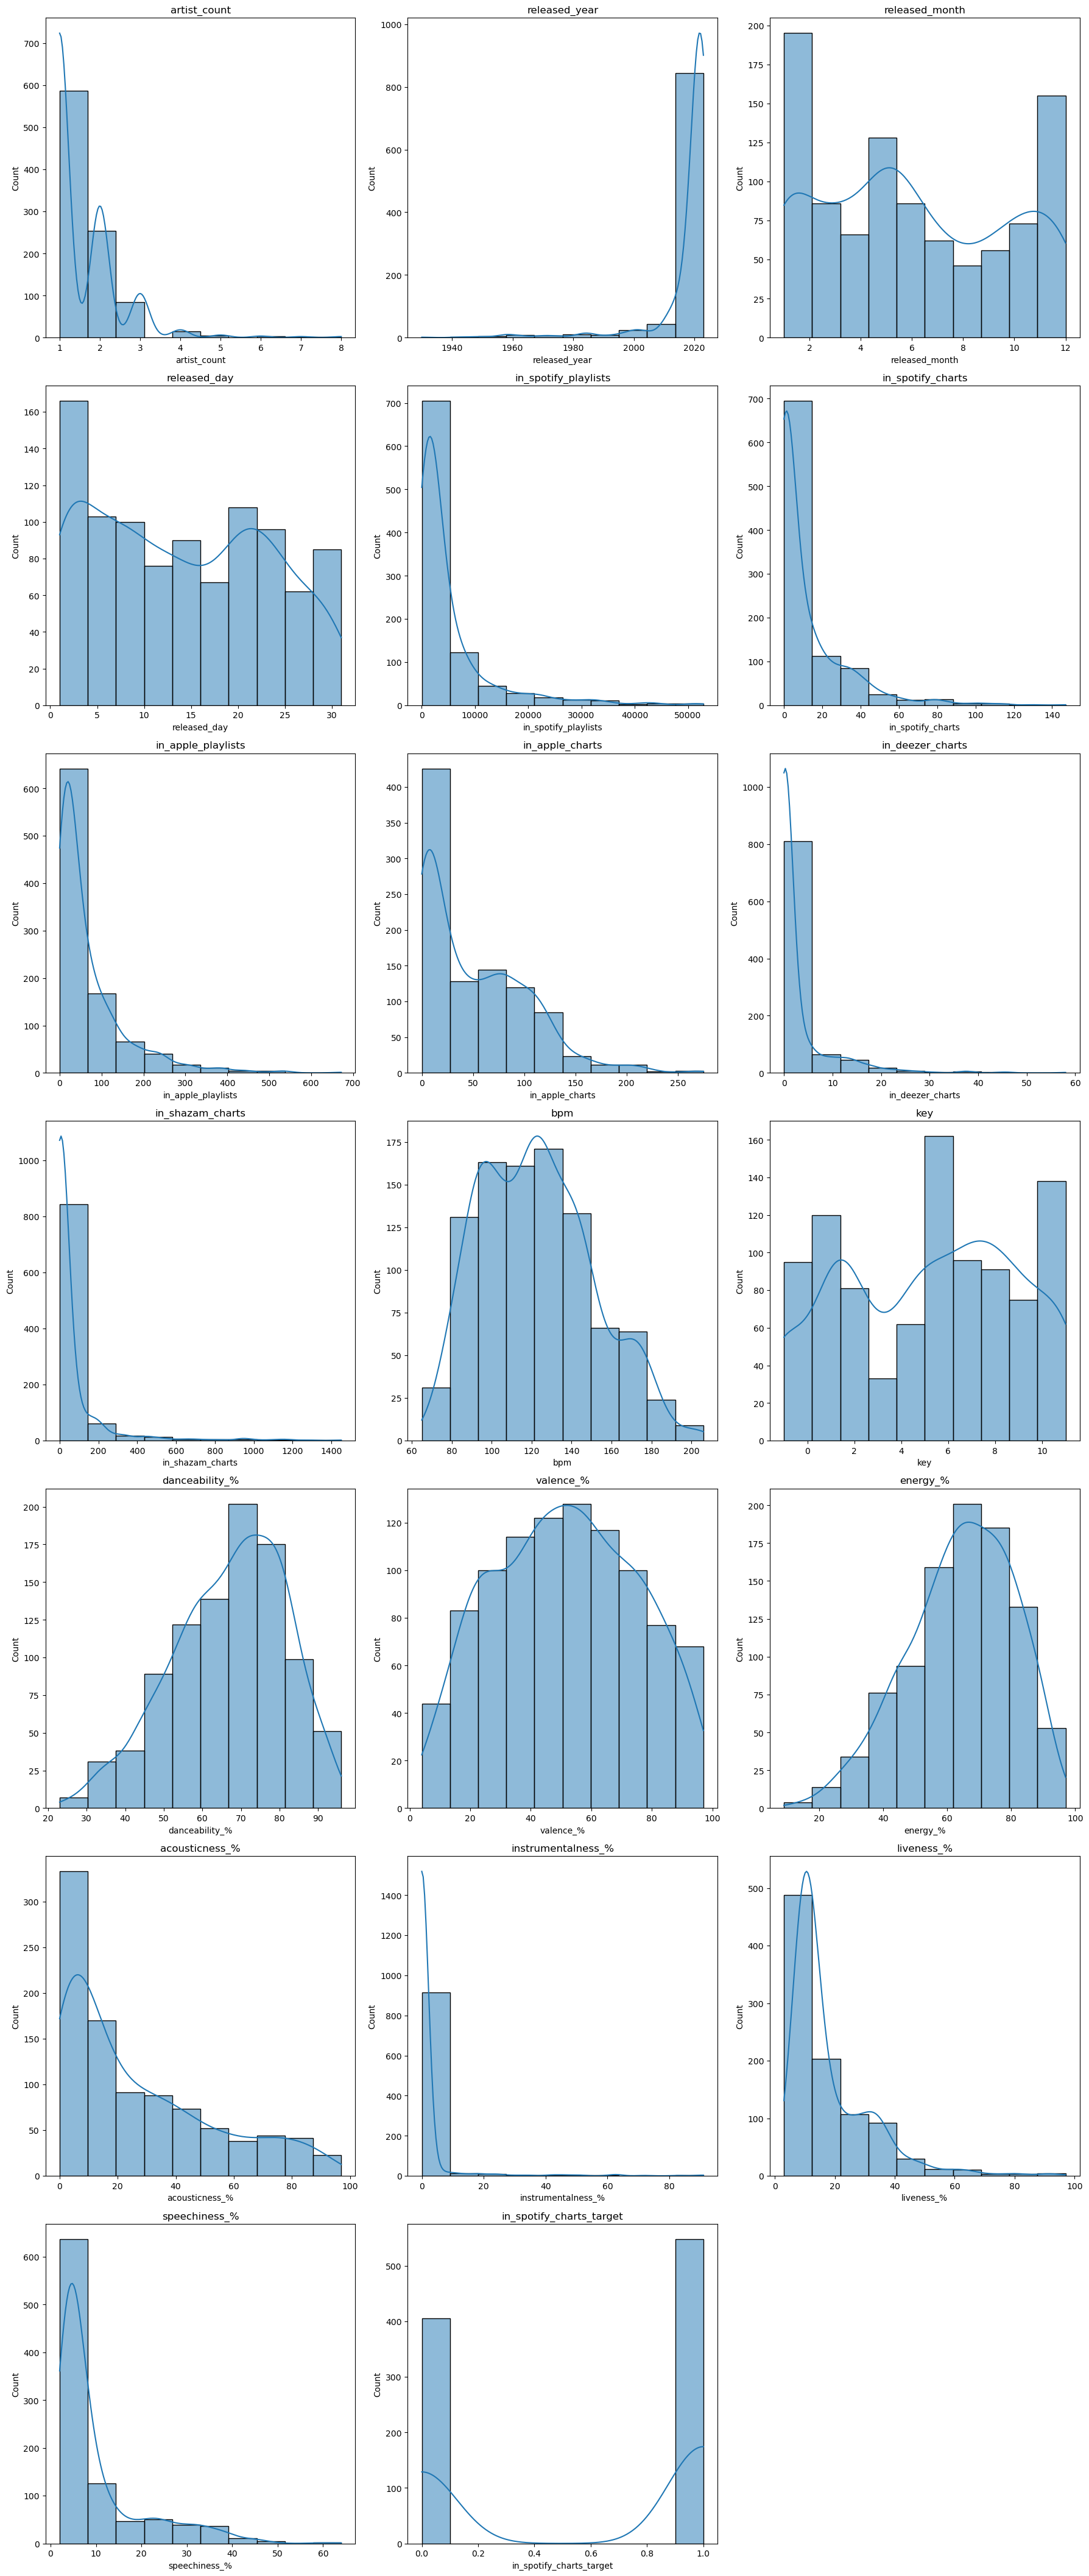

In [17]:
coloane_numerice = df.select_dtypes(include=['int64']).columns

numar_randuri = len(coloane_numerice) // 3 + len(coloane_numerice) % 3
numar_coloane = 3

plt.figure(figsize=(18, numar_randuri * 6))
for index, col in enumerate(coloane_numerice):
    plt.subplot(numar_randuri, numar_coloane, index+1)
    sns.histplot(data=df, x=col, bins=10, kde=True)
    plt.title(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

### Statistici simple

In [18]:
print("statisticile simple pentru dataframe sunt:")
display(df.describe().T)

statisticile simple pentru dataframe sunt:


,count,mean,std,min,25%,50%,75%,max
artist_count,953.0,1.556139,0.893044,1.0,1.0,1.0,2.0,8.0
released_year,953.0,2018.238195,11.116218,1930.0,2020.0,2022.0,2022.0,2023.0
released_month,953.0,6.033578,3.566435,1.0,3.0,6.0,9.0,12.0
released_day,953.0,13.930745,9.201949,1.0,6.0,13.0,22.0,31.0
in_spotify_playlists,953.0,5200.124869,7897.608990,31.0,875.0,2224.0,5542.0,52898.0
in_spotify_charts,953.0,12.009444,19.575992,0.0,0.0,3.0,16.0,147.0
in_apple_playlists,953.0,67.812172,86.441493,0.0,13.0,34.0,88.0,672.0
in_apple_charts,953.0,51.908709,50.630241,0.0,7.0,38.0,87.0,275.0
in_deezer_charts,953.0,2.666317,6.035599,0.0,0.0,0.0,2.0,58.0
in_shazam_charts,953.0,56.847849,157.441749,0.0,0.0,2.0,33.0,1451.0


### Analiza valori extreme

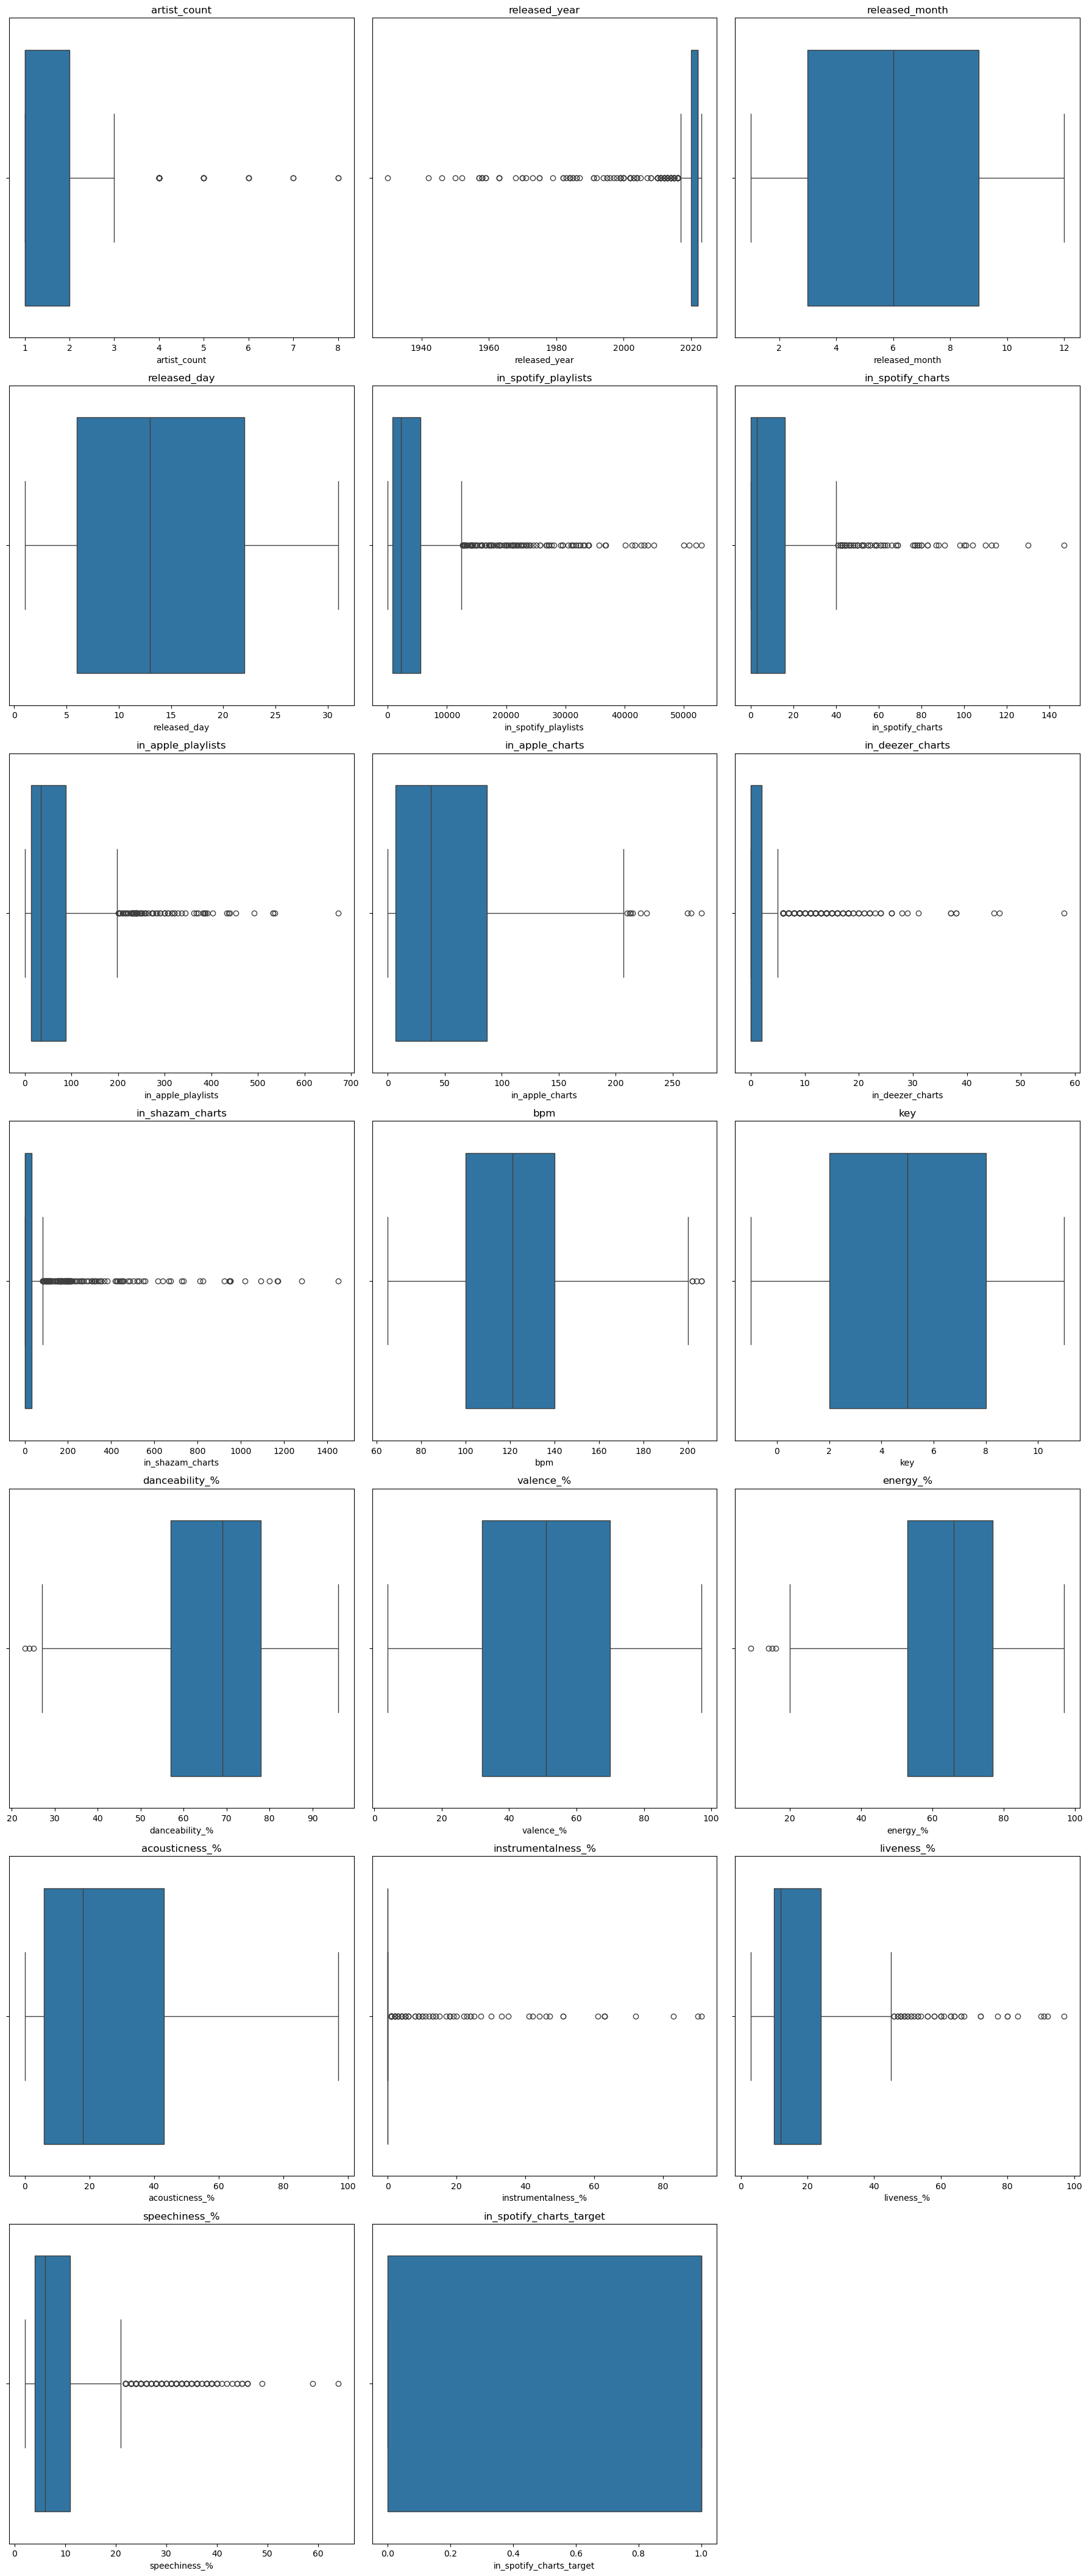

In [19]:
#vizualizarea valorilor extreme
plt.figure(figsize=(18, numar_randuri * 6))

for index, col in enumerate(coloane_numerice):
    plt.subplot(numar_randuri, numar_coloane, index+1)
    sns.boxplot(data=df, x=col)
    plt.title(col)

plt.tight_layout()
plt.show()

In [20]:
#metoda interquantile range pentru vizualizarea valorilor extreme
for col in coloane_numerice:
    
    #valorile coloanei curente
    arr = df[col].values  
    
    # calculul q1, q3, med si iqr
    q1 = np.quantile(arr, 0.25)
    q3 = np.quantile(arr, 0.75)
    med = np.median(arr)
    iqr = q3 - q1

    #calculul limitelor superioare si inferioare
    limita_superioara = q3 + (1.5 * iqr)
    limita_inferioara = q1 - (1.5 * iqr)

    #valorilor extreme in coloana curenta
    outliers = arr[(arr <= limita_inferioara) | (arr >= limita_superioara)]

    # numarul de valori aberante din coloana curenta
    numar_outliers = len(outliers)

    print(f"coloana: {col}")
    print(f"IQR: {iqr}, limita superioara: {limita_superioara}, limita inferioara: {limita_inferioara}")
    print("valori extreme: ", outliers)
    print(f"numar de valori extreme: {numar_outliers}\n")

coloana: artist_count
IQR: 1.0, limita superioara: 3.5, limita inferioara: -0.5
valori extreme:  [8 4 5 4 4 4 5 5 5 4 6 6 4 4 7 4 4 4 8 7 4 6 4 4 5 4 4]
numar de valori extreme: 27

coloana: released_year
IQR: 2.0, limita superioara: 2025.0, limita inferioara: 2017.0
valori extreme:  [2013 2014 2014 2017 2016 2016 2012 1999 2012 2008 1975 2015 2012 2017
 2011 2012 2004 2017 2017 2011 2012 1985 2014 2011 2017 2011 2007 2017
 2017 2002 2016 2004 2010 2012 2013 2004 2016 2010 2010 1983 2015 2011
 2012 2013 2012 2016 2014 2013 2017 2014 1992 2017 2016 2010 2013 1968
 2010 1984 2016 2000 1997 2014 2002 2002 1995 2014 2017 2016 2015 2003
 2011 2000 2017 2016 2016 2015 2014 2017 2014 2015 1985 1973 1930 2012
 1994 1984 1958 1957 2011 2013 1963 1959 2017 2013 1970 2011 2011 1963
 1971 1952 1946 1979 1984 1984 1950 1942 1986 1963 2017 1958 2000 1959
 2005 1958 1957 2017 2017 1970 2015 2015 2010 2016 2016 2017 2010 2014
 2017 2013 1991 2003 2002 1999 1999 2012 2002 2013 2016 1995 1999 2017
 1999

In [21]:
coloane_numerice = ["in_apple_charts", "bpm", "danceability_%", "energy_%"]
for col in coloane_numerice:
    #valorile coloanei curente
    arr = df[col].values
    
    # calculul q1, q3 si iqr
    q1 = np.quantile(arr, 0.25)
    q3 = np.quantile(arr, 0.75)
    iqr = q3 - q1

    #calculul limitelor superioare si inferioare
    limita_superioara = q3 + (1.5 * iqr)
    limita_inferioara = q1 - (1.5 * iqr)

    #indexurile valorilor extreme din coloana curenta
    outliers_index = df[(arr <= limita_inferioara) | (arr >= limita_superioara)].index

    #eliminarea inregistrarilor cu valori extreme 
    df = df.drop(outliers_index)

df = df.reset_index(drop=True)
display(df)

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,in_spotify_charts_target
0,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,1,Major,71,61,74,7,0,10,4,1
1,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,9,Minor,65,23,80,14,63,11,6,1
2,Columbia,Quevedo,1,2023,7,7,714,43,58149378,25,...,5,Major,67,26,71,37,0,11,4,1
3,La Bebe - Remix,"Peso Pluma, Yng Lvcas",2,2023,3,17,2953,44,553634067,49,...,2,Minor,81,56,48,21,0,8,33,1
4,un x100to,"Bad Bunny, Grupo Frontera",2,2023,4,17,2876,40,505671438,41,...,6,Minor,57,56,72,23,0,27,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
927,My Mind & Me,Selena Gomez,1,2022,11,3,953,0,91473363,61,...,9,Major,60,24,39,57,0,8,3,0
928,Bigger Than The Whole Sky,Taylor Swift,1,2022,10,21,1180,0,121871870,4,...,6,Major,42,7,24,83,1,12,6,0
929,A Veces (feat. Feid),"Feid, Paulo Londra",2,2022,11,3,573,0,73513683,2,...,1,Major,80,81,67,4,0,8,6,0
930,En La De Ella,"Feid, Sech, Jhayco",3,2022,10,20,1320,0,133895612,29,...,1,Major,82,67,77,8,0,12,5,0


### Analiza valori aberante/erori umane

In [22]:
duplicat_track_name = df[df.duplicated(subset=['track_name'], keep=False)]

if not duplicat_track_name.empty:
    numar_duplicat = len(duplicat_track_name)
    print(f"Exista {numar_duplicat} inregistrari duplicate in coloana 'track_name'.")
    print("Valorile duplicate in 'track_name' sunt urmatoarele:")
    print(duplicat_track_name['track_name'].unique())
else:
    print("Nu exista inregistrari duplicate in coloana 'track_name'.")

Exista 18 inregistrari duplicate in coloana 'track_name'.
Valorile duplicate in 'track_name' sunt urmatoarele:
['Daylight' 'Die For You' 'SNAP' 'Numb' 'Miss You' 'SPIT IN MY FACE!'
 'About Damn Time' 'Let It Snow! Let It Snow! Let It Snow!'
 'Take My Breath']


In [23]:
#afisez inregistrarile pentru valoarea "Take My Breath" din coloana "track_name"

filtre = df['track_name'] == 'Take My Breath'
inregistrari_take_my_breath = df.loc[filtre]

if not inregistrari_take_my_breath.empty:
    print("Atributele cu valorile corespunzatoare pentru 'Take My Breath':")
    display(inregistrari_take_my_breath)
else:
    print("Nu exista inregistrari pentru 'Take My Breath'.")

Atributele cu valorile corespunzatoare pentru 'Take My Breath':


,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,in_spotify_charts_target
494,Take My Breath,The Weeknd,1,2021,8,6,2597,0,130655803,17,...,10,Minor,70,35,77,1,0,26,4,0
598,Take My Breath,The Weeknd,1,2021,8,6,6392,0,432702334,174,...,8,Major,75,53,74,2,0,11,5,0


In [24]:
#se sterge inregistrarea de la indexul 494
df = df.drop(494)

#resetarea indexului pentru a reorganiza DataFrame-ul
df = df.reset_index(drop=True)

In [25]:
#afisez inregistrarile pentru valoarea "About Damn Time" din coloana "track_name"

filtre = df['track_name'] == 'About Damn Time'
inregistrari_take_my_breath = df.loc[filtre]

if not inregistrari_take_my_breath.empty:
    print("Atributele cu valorile corespunzatoare pentru 'About Damn Time':")
    display(inregistrari_take_my_breath)
else:
    print("Nu exista inregistrari pentru 'About Damn Time'.")

Atributele cu valorile corespunzatoare pentru 'About Damn Time':


,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,in_spotify_charts_target
359,About Damn Time,Lizzo,1,2022,7,15,2332,2,723894473,0,...,10,Minor,84,72,74,10,0,34,7,1
745,About Damn Time,Lizzo,1,2022,4,14,9021,0,723894473,242,...,10,Minor,84,72,74,10,0,34,7,0


In [26]:
#se sterge inregistrarea de la indexul 359
df = df.drop(359)
#resetarea indexului pentru a reorganiza DataFrame-ul
df = df.reset_index(drop=True)

In [27]:
#afisez inregistrarile pentru valoarea "SPIT IN MY FACE!" din coloana "track_name"

filtre = df['track_name'] == 'SPIT IN MY FACE!'
inregistrari_take_my_breath = df.loc[filtre]

if not inregistrari_take_my_breath.empty:
    print("Atributele cu valorile corespunzatoare pentru 'SPIT IN MY FACE!':")
    display(inregistrari_take_my_breath)
else:
    print("Nu exista inregistrari pentru 'SPIT IN MY FACE!'.")

Atributele cu valorile corespunzatoare pentru 'SPIT IN MY FACE!':


,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,in_spotify_charts_target
332,SPIT IN MY FACE!,ThxSoMch,1,2022,10,31,629,14,303216294,32,...,8,Major,73,65,79,5,2,11,6,1
464,SPIT IN MY FACE!,ThxSoMch,1,2022,10,31,573,0,301869854,1,...,1,Major,70,57,57,9,20,11,7,0


In [28]:
#se sterge inregistrarea de la indexul 464
df = df.drop(464)
#resetarea indexului pentru a reorganiza DataFrame-ul
df = df.reset_index(drop=True)

In [29]:
#afisez inregistrarile pentru valoarea "SNAP" din coloana "track_name"

filtre = df['track_name'] == 'SNAP'
inregistrari_take_my_breath = df.loc[filtre]

if not inregistrari_take_my_breath.empty:
    print("Atributele cu valorile corespunzatoare pentru 'SNAP':")
    display(inregistrari_take_my_breath)
else:
    print("Nu exista inregistrari pentru 'SNAP'.")

Atributele cu valorile corespunzatoare pentru 'SNAP':


,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,in_spotify_charts_target
167,SNAP,Rosa Linn,1,2022,3,19,3202,18,726307468,148,...,-1,Major,56,53,64,11,0,45,6,1
851,SNAP,Rosa Linn,1,2022,3,19,1818,0,711366595,3,...,-1,Major,56,52,64,11,0,45,7,0


In [30]:
#se sterge inregistrarea de la indexul 851
df = df.drop(851)
#resetarea indexului pentru a reorganiza DataFrame-ul
df = df.reset_index(drop=True)

In [31]:
df['in_deezer_playlists'] = df['in_deezer_playlists'].replace(',', '', regex=True).astype('int64')
#df.info()

In [32]:
# se converteste coloana "streams" la numeric si se identifica acele valori care nu pot fi convertite
non_numeric_streams = df[pd.to_numeric(df['streams'], errors='coerce').isna()]

if not non_numeric_streams.empty:
    print("Valorile non-numerice sunt: ")
    display(non_numeric_streams)
else:
    print("Toate valorile din coloana 'streams' sunt numerice.")

Valorile non-numerice sunt: 


,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,in_spotify_charts_target
553,Love Grows (Where My Rosemary Goes),Edison Lighthouse,1,1970,1,1,2877,0,BPM110KeyAModeMajorDanceability53Valence75Ener...,16,...,9,Major,53,75,69,7,0,17,3,0


In [33]:
#se sterge inregistrarea de la indexul 553
df = df.drop(553)
#resetarea indexului pentru a reorganiza DataFrame-ul
df = df.reset_index(drop=True)

In [34]:
df['streams'] = df['streams'].astype('int64')

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 927 entries, 0 to 926
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   track_name                927 non-null    object
 1   artist(s)_name            927 non-null    object
 2   artist_count              927 non-null    int64 
 3   released_year             927 non-null    int64 
 4   released_month            927 non-null    int64 
 5   released_day              927 non-null    int64 
 6   in_spotify_playlists      927 non-null    int64 
 7   in_spotify_charts         927 non-null    int64 
 8   streams                   927 non-null    int64 
 9   in_apple_playlists        927 non-null    int64 
 10  in_apple_charts           927 non-null    int64 
 11  in_deezer_playlists       927 non-null    int64 
 12  in_deezer_charts          927 non-null    int64 
 13  in_shazam_charts          927 non-null    int64 
 14  bpm                       

## 3. Matricea de corelatie

### Pentru variabile numerice matricea de corelatie Pearson

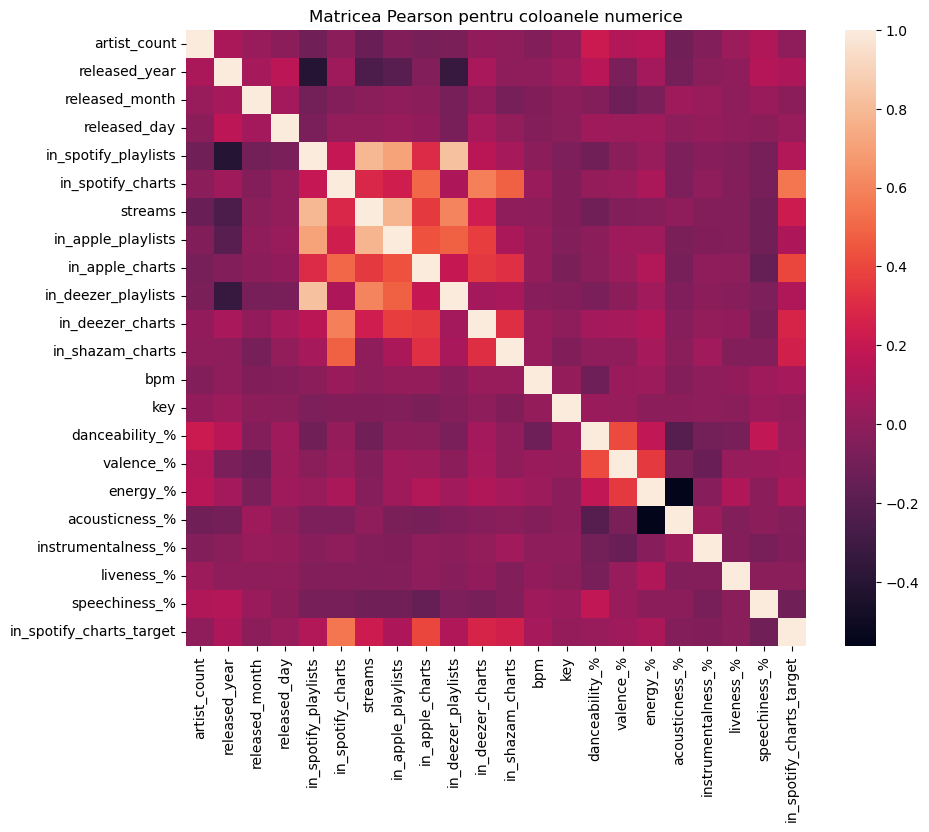

In [36]:
coloane_numerice = df.select_dtypes(include=['int64']).columns

#standardizarea coloanelor numerice
scaler = StandardScaler()
df_standardizat_numeric = pd.DataFrame(scaler.fit_transform(df[coloane_numerice]), columns=coloane_numerice)

plt.figure(figsize=(10, 8))
sns.heatmap(df_standardizat_numeric.corr())
plt.title("Matricea Pearson pentru coloanele numerice")
plt.show()

### Pentru variabile categoriale, dupa codificarea valorilor categoriale, matricea de corelatie Spearman

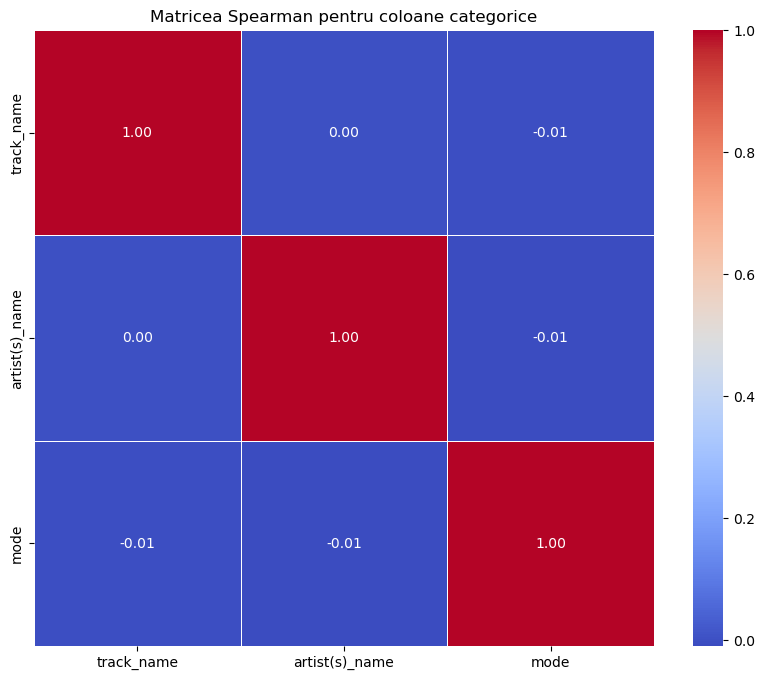

In [37]:
df_copy=df.copy()
label_encoder = LabelEncoder()
coloane_categoriale = df_copy.select_dtypes(include=['object']).columns

for col in coloane_categoriale:
    df_copy[col] = label_encoder.fit_transform(df_copy[col])

scaler = StandardScaler()
df_standardized = pd.DataFrame(scaler.fit_transform(df_copy[coloane_categoriale]), columns=coloane_categoriale)


plt.figure(figsize=(10, 8))
sns.heatmap(df_standardized.corr(method='spearman'), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Matricea Spearman pentru coloane categorice")
plt.show()

### Gasirea componentelor principale

In [38]:
pca = PCA(n_components =3)
pca.fit(df_standardizat_numeric)
data_pca = pca.transform(df_standardizat_numeric)
data_pca = pd.DataFrame(data_pca,columns=['PC1','PC2','PC3'])
data_pca.head()

,PC1,PC2,PC3
0,1.730725,3.398122,1.645640
1,2.064517,2.643961,3.763400
2,0.743722,1.844751,2.326169
3,1.342100,2.828227,1.404202
4,1.999074,2.717962,1.696580


[pca] >Extracting column labels from dataframe.
[pca] >Extracting row labels from dataframe.
[pca] >The PCA reduction is performed to capture [90.0%] explained variance using the [22] columns of the input data.
[pca] >Fit using PCA.
[pca] >Compute loadings and PCs.
[pca] >Compute explained variance.
[pca] >Number of components is [16] that covers the [90.00%] explained variance.
[pca] >The PCA reduction is performed on the [22] columns of the input dataframe.
[pca] >Fit using PCA.
[pca] >Compute loadings and PCs.
[pca] >Outlier detection using Hotelling T2 test with alpha=[0.05] and n_components=[16]
[pca] >Multiple test correction applied for Hotelling T2 test: [fdr_bh]
[pca] >Outlier detection using SPE/DmodX with n_std=[3]


[scatterd] >INFO> Create scatterplot
[scatterd] >INFO> Create scatterplot


[pca] >Plot PC1 vs PC2 with loadings.


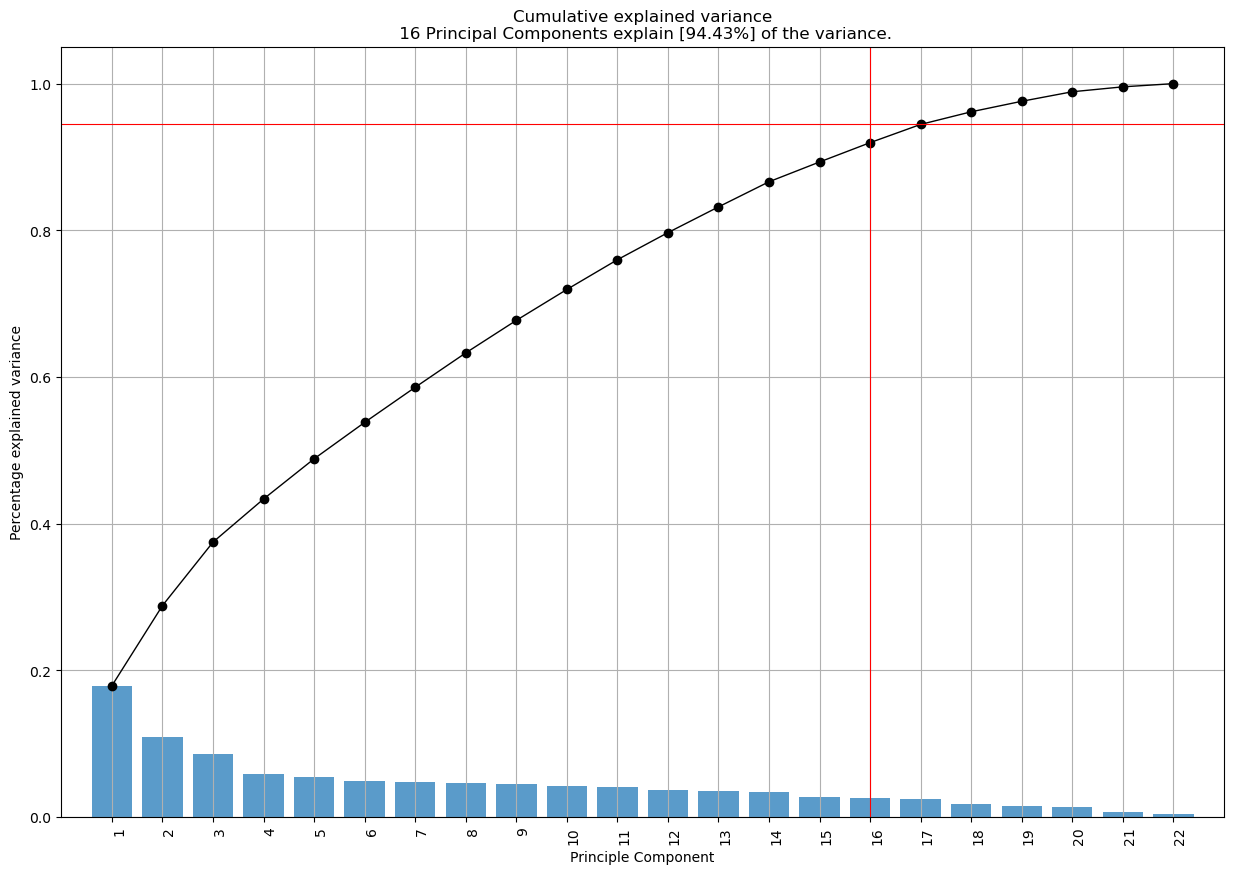

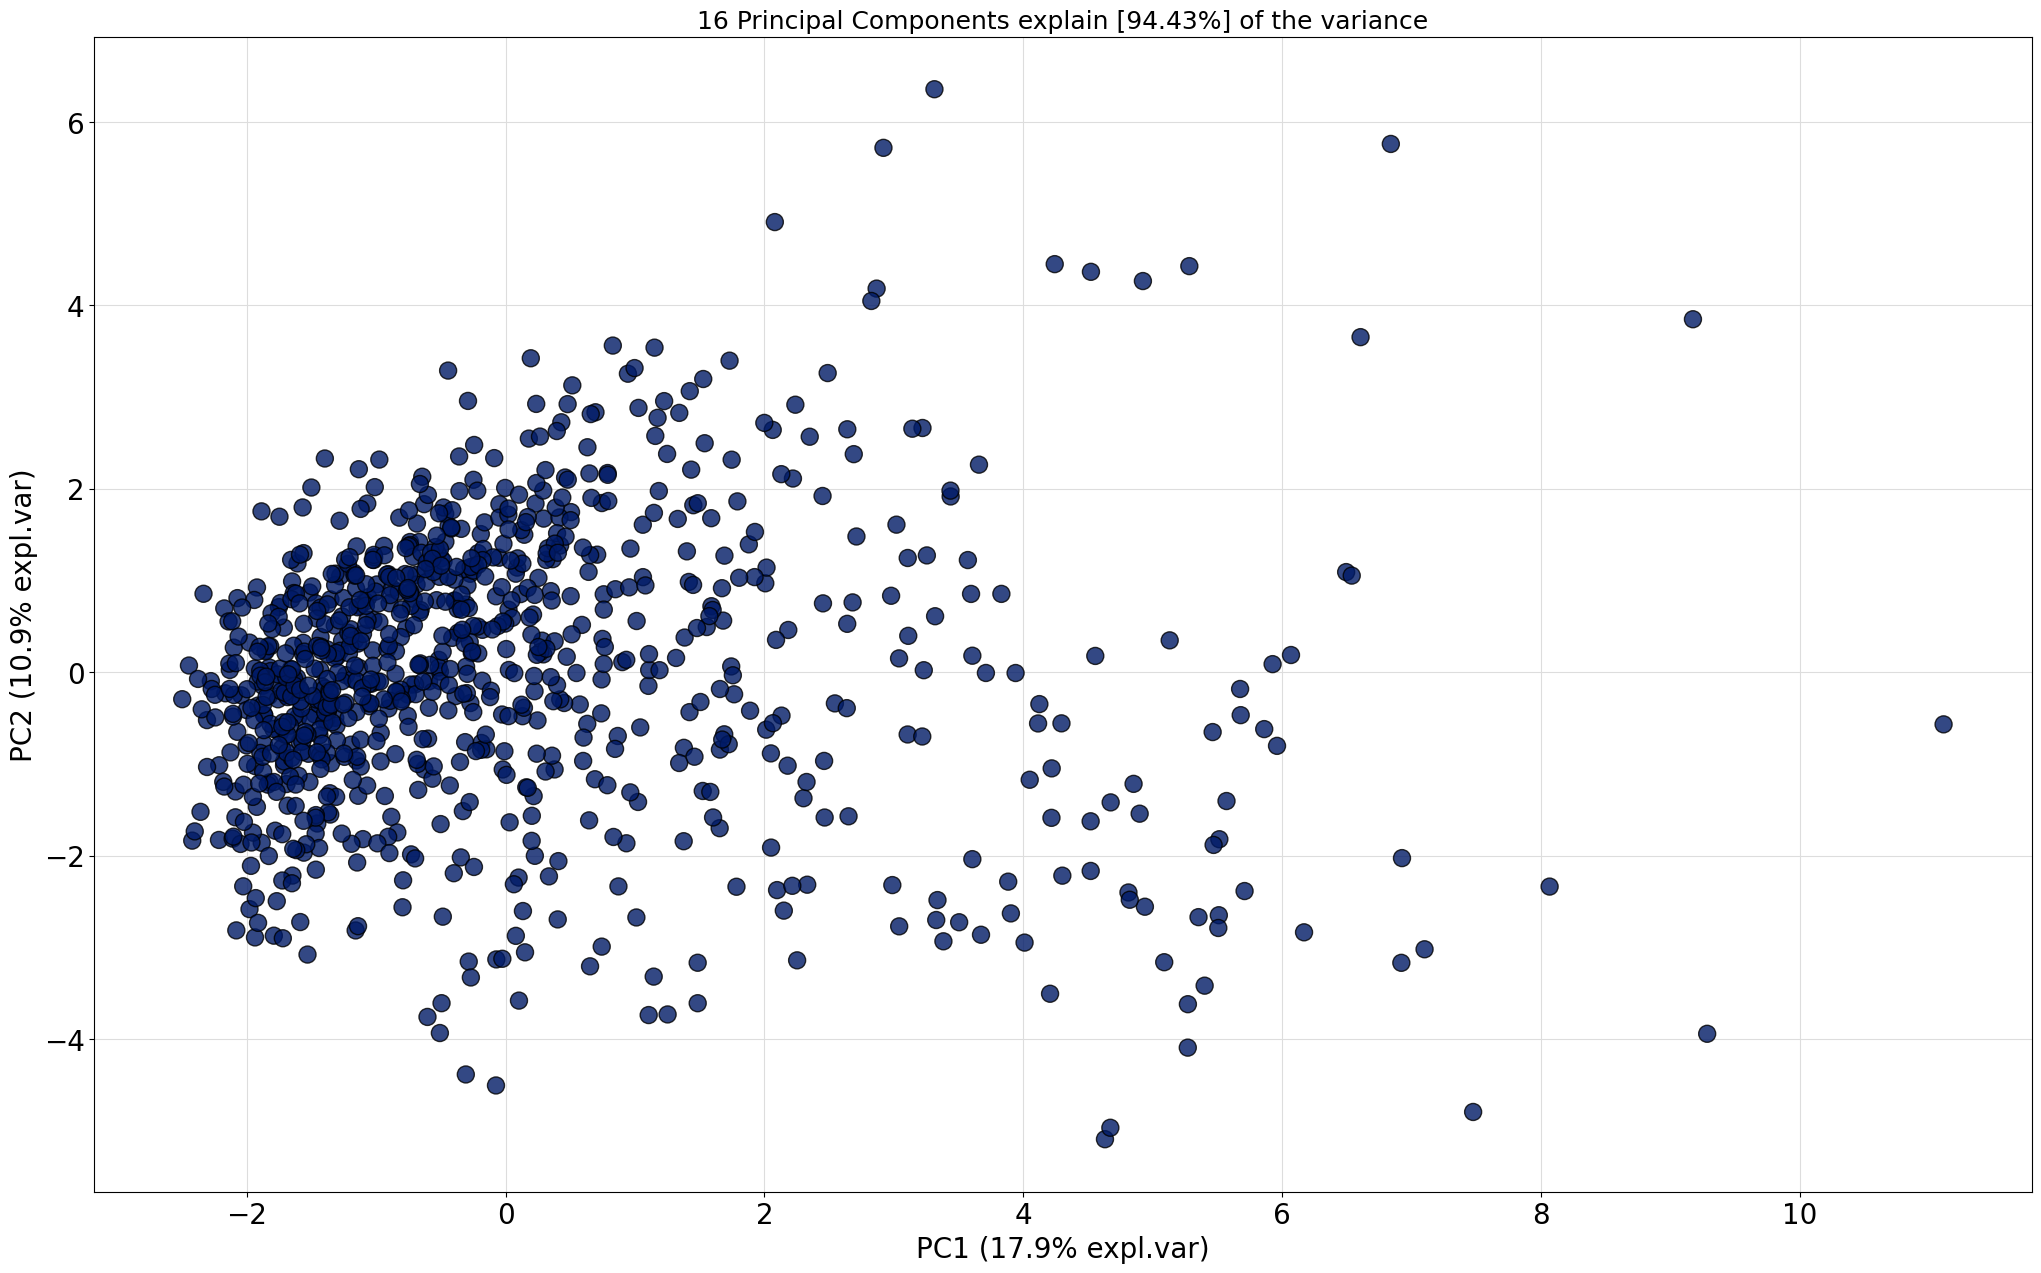

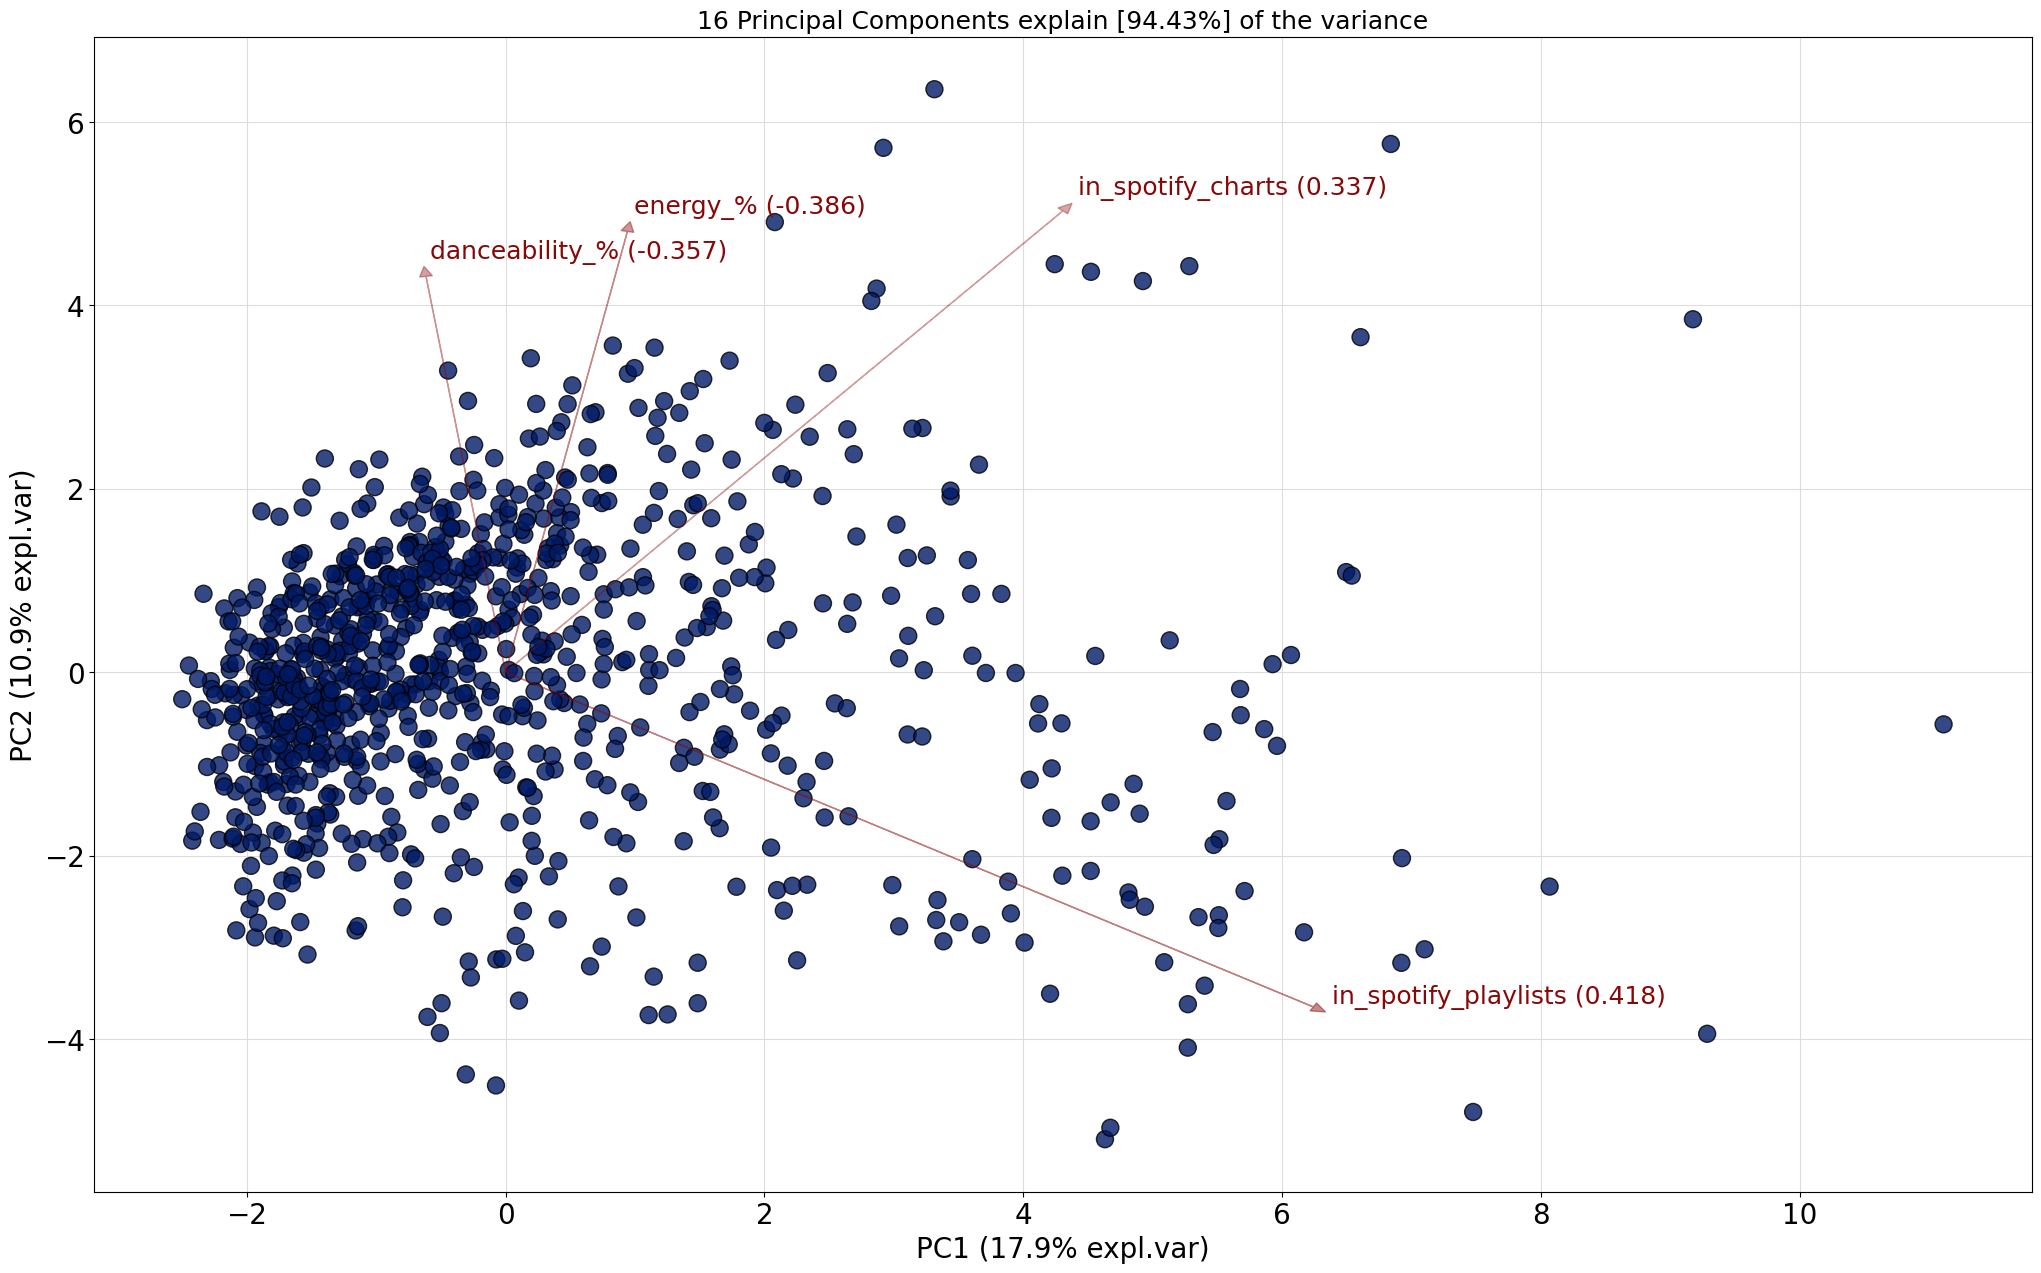

In [39]:
from pca import pca

model = pca(n_components=0.90)
results = model.fit_transform(X=df_standardizat_numeric)

# grafic de bare cu varianta explicata
fig, ax = model.plot()

# scatter plot cu primele doua componente
fig, ax = model.scatter()

# biplot
fig, ax = model.biplot(n_feat=4)

## 4. Tendinte, trenduri, relatii intre variabile 

### Distributia atributelor pe clasele care trebuie prognozate

In [40]:
matrice_corelatie = df_standardizat_numeric.corr()
print(matrice_corelatie['in_spotify_charts_target'].sort_values(ascending=False))

in_spotify_charts_target    1.000000
in_spotify_charts           0.550569
in_apple_charts             0.397430
in_deezer_charts            0.270718
in_shazam_charts            0.245538
streams                     0.221387
in_spotify_playlists        0.125881
in_deezer_playlists         0.113161
released_year               0.107809
in_apple_playlists          0.104519
energy_%                    0.096712
bpm                         0.078637
valence_%                   0.049947
released_day                0.035058
danceability_%              0.033614
key                         0.017852
artist_count                0.003933
released_month             -0.010288
liveness_%                 -0.023305
acousticness_%             -0.041376
instrumentalness_%         -0.051242
speechiness_%              -0.111883
Name: in_spotify_charts_target, dtype: float64


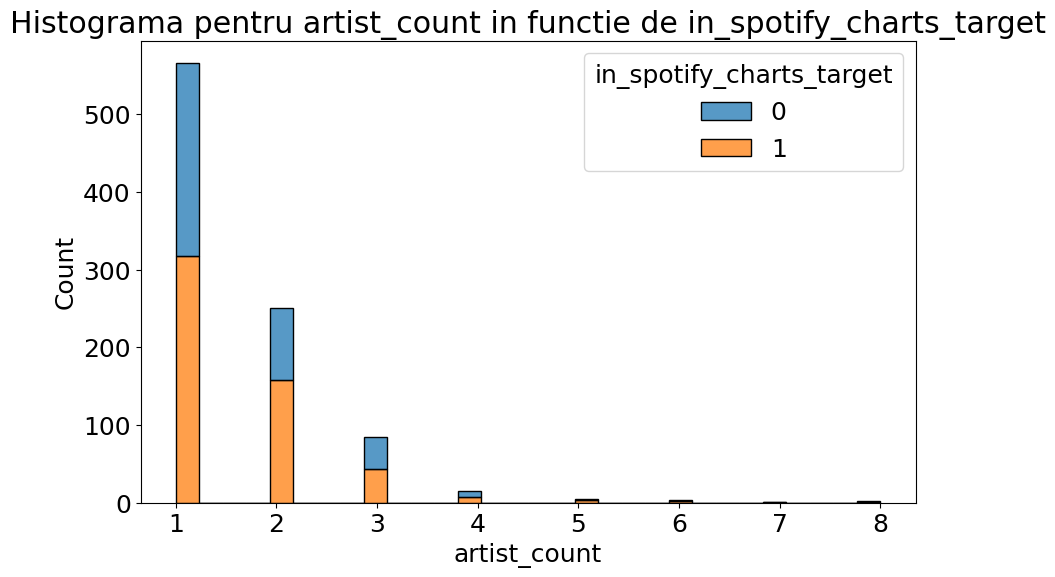

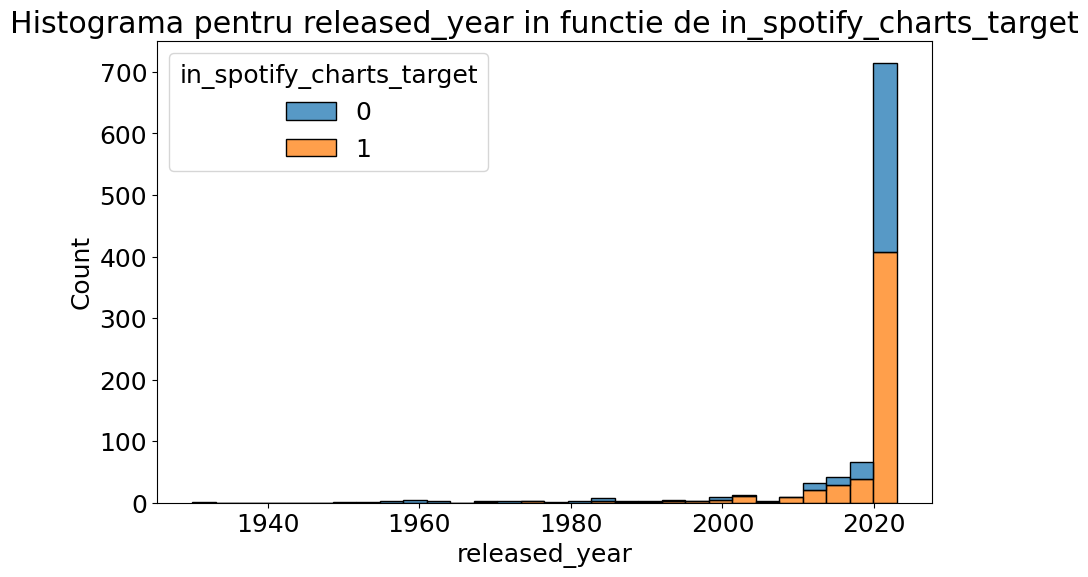

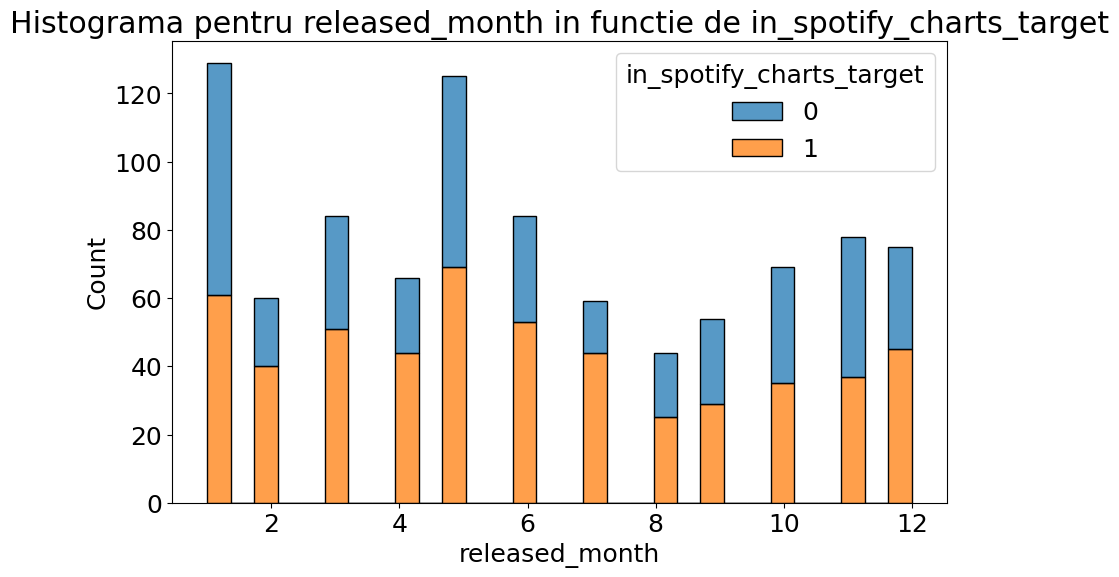

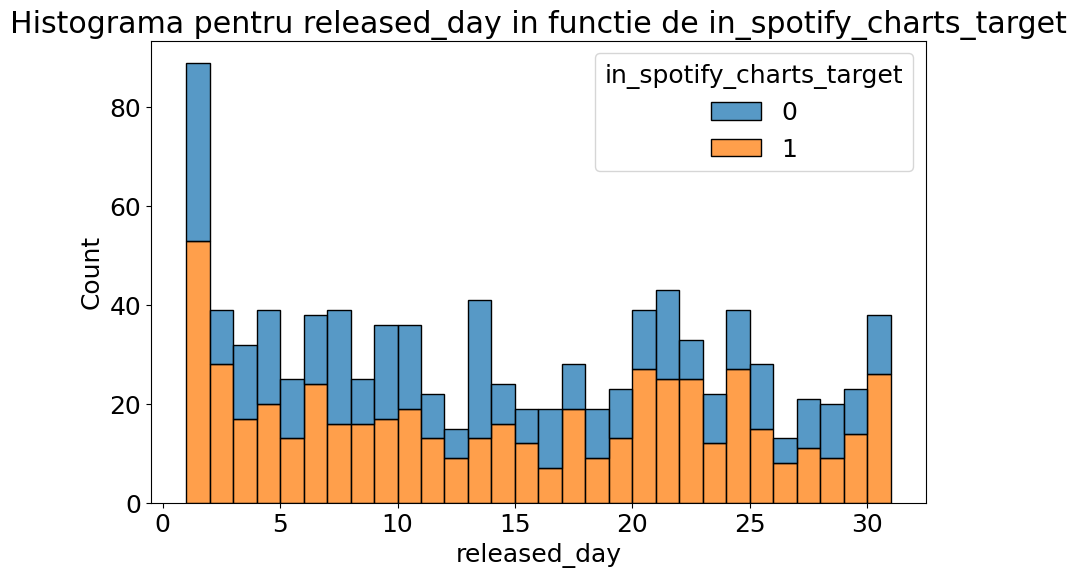

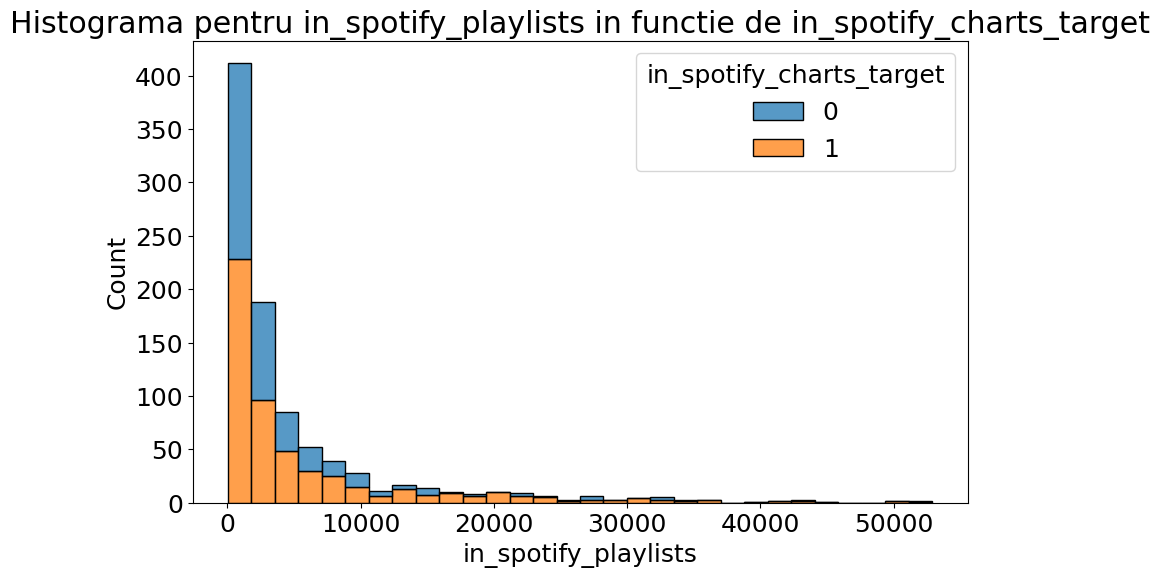

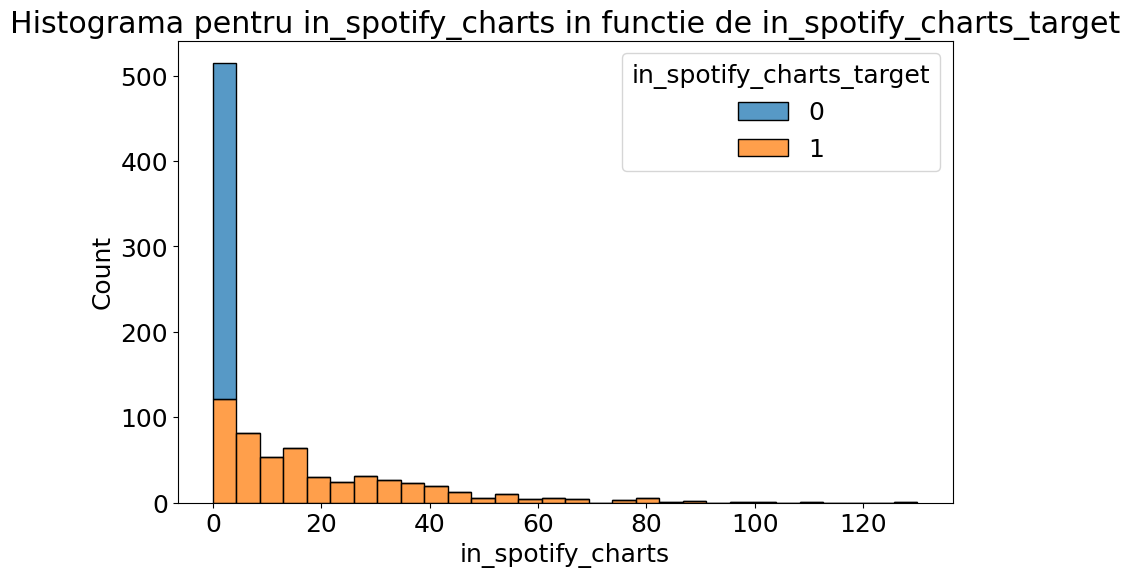

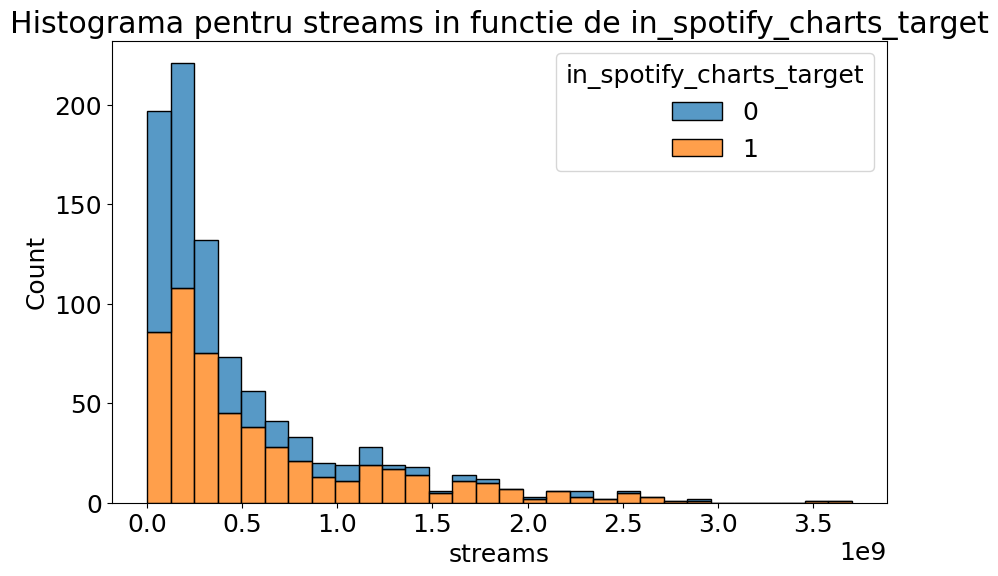

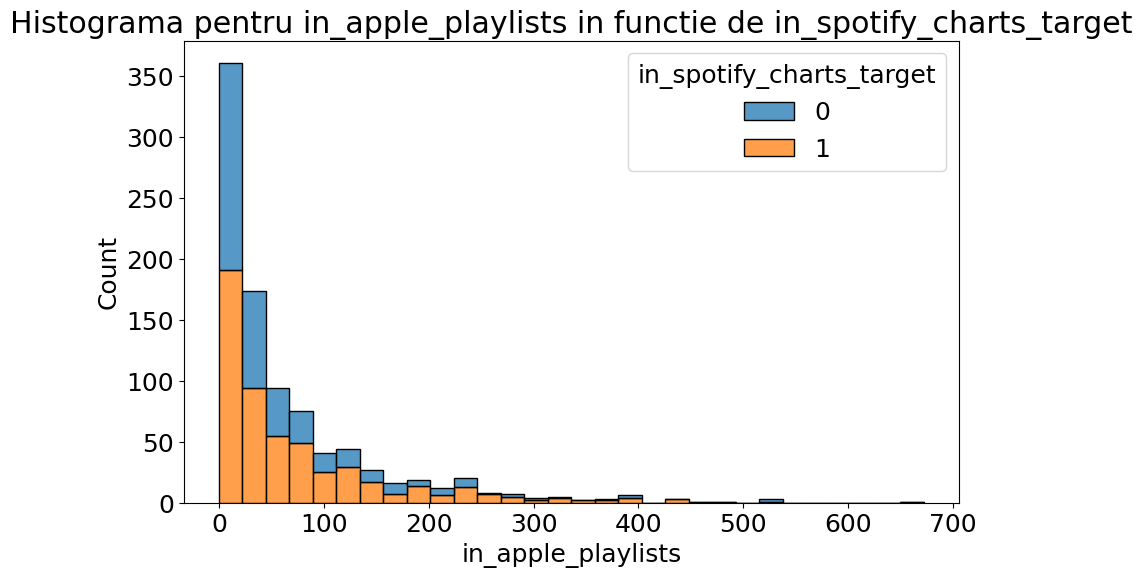

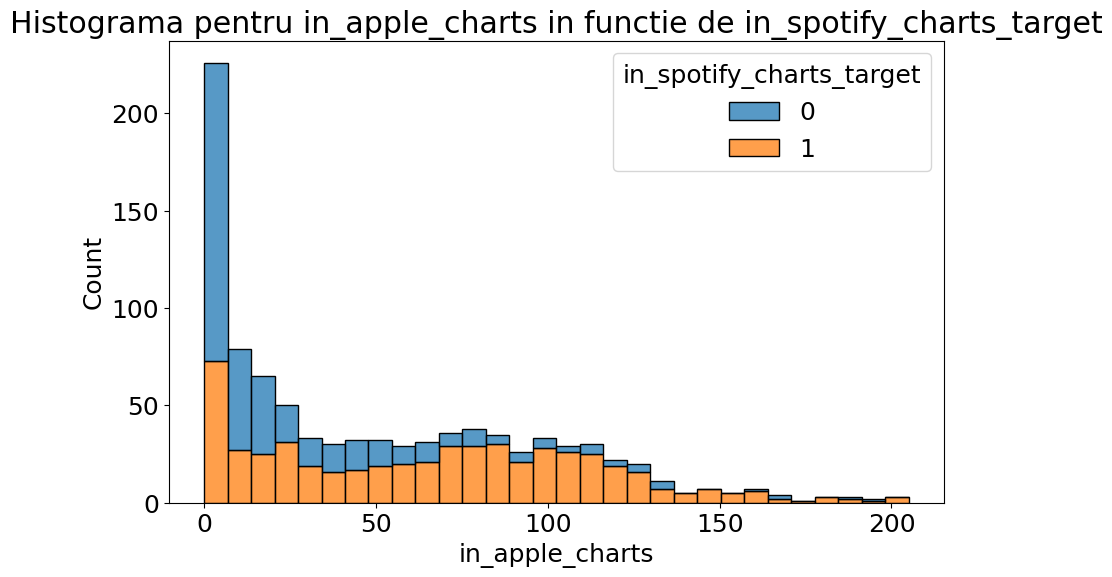

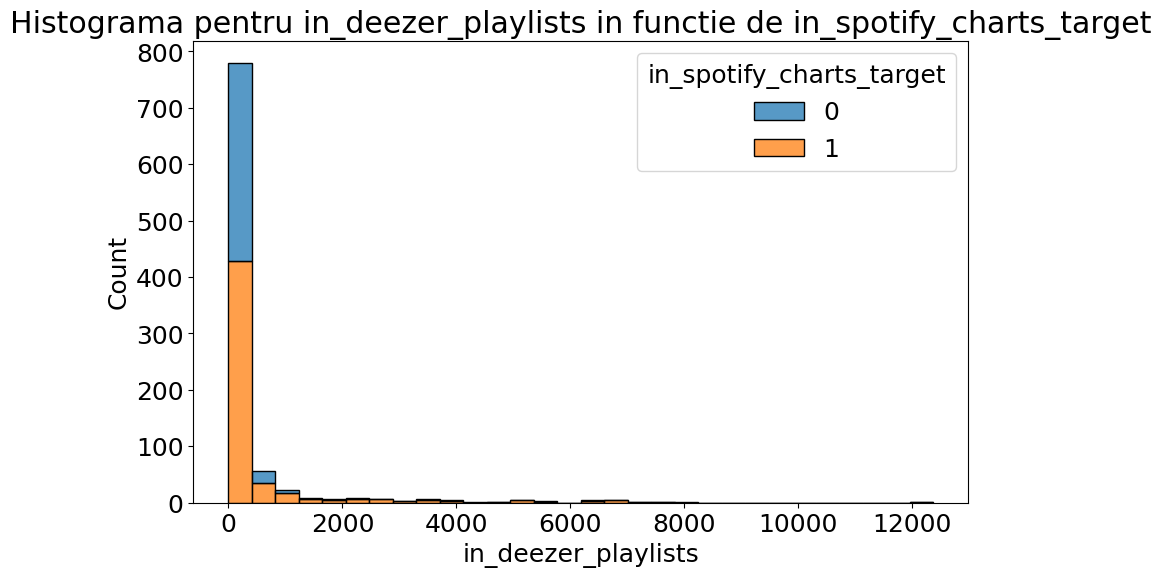

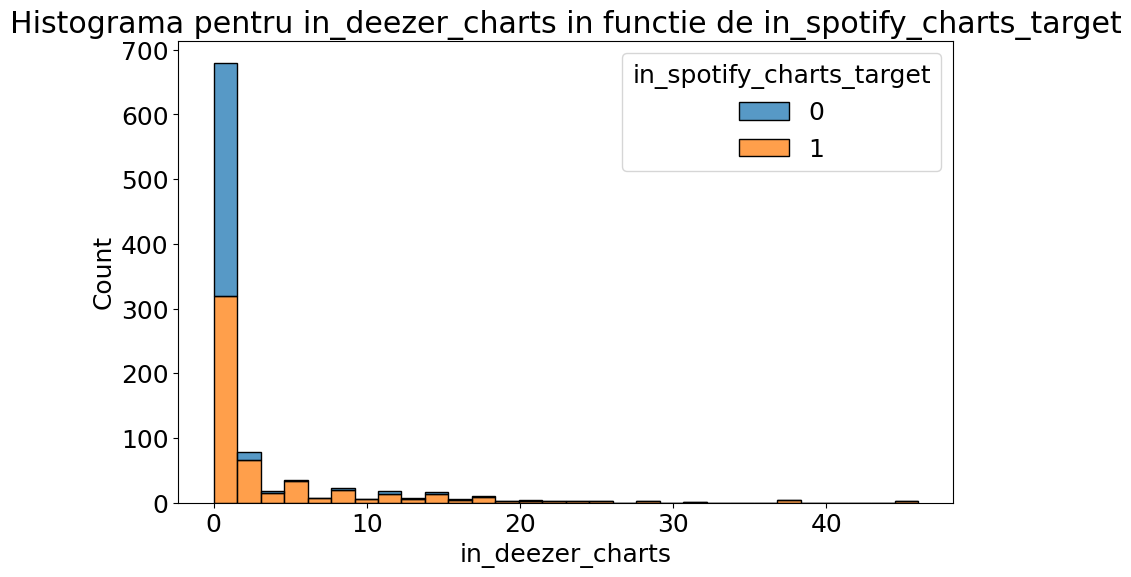

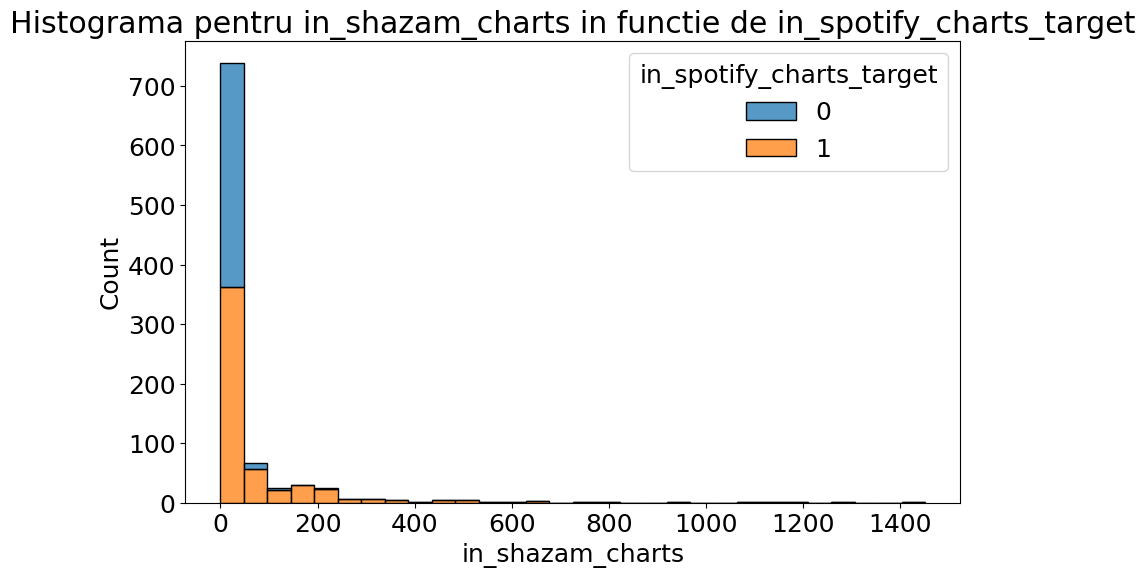

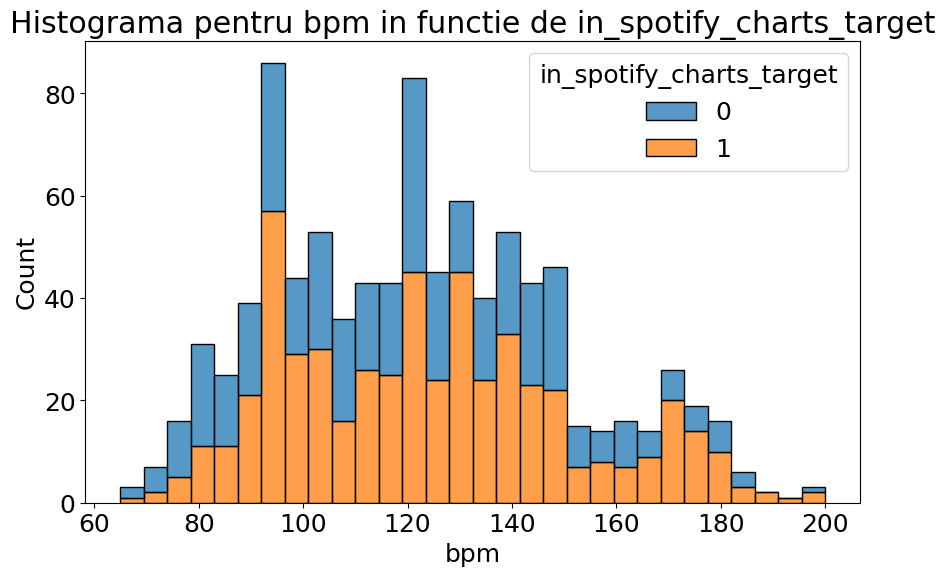

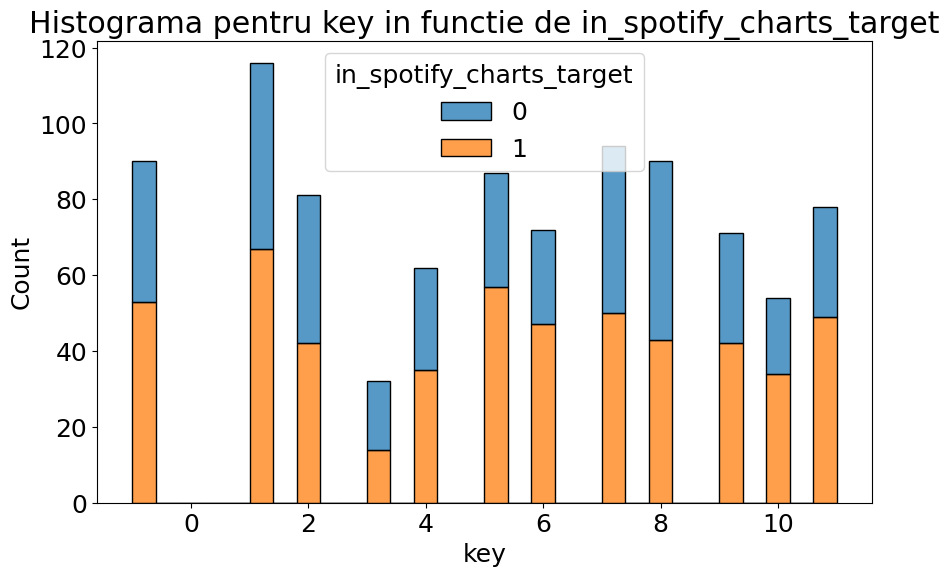

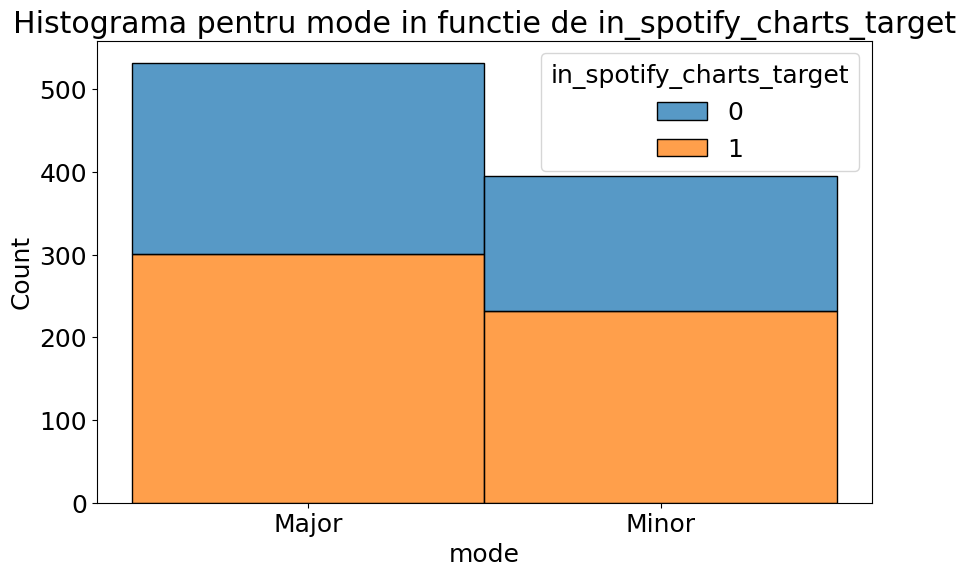

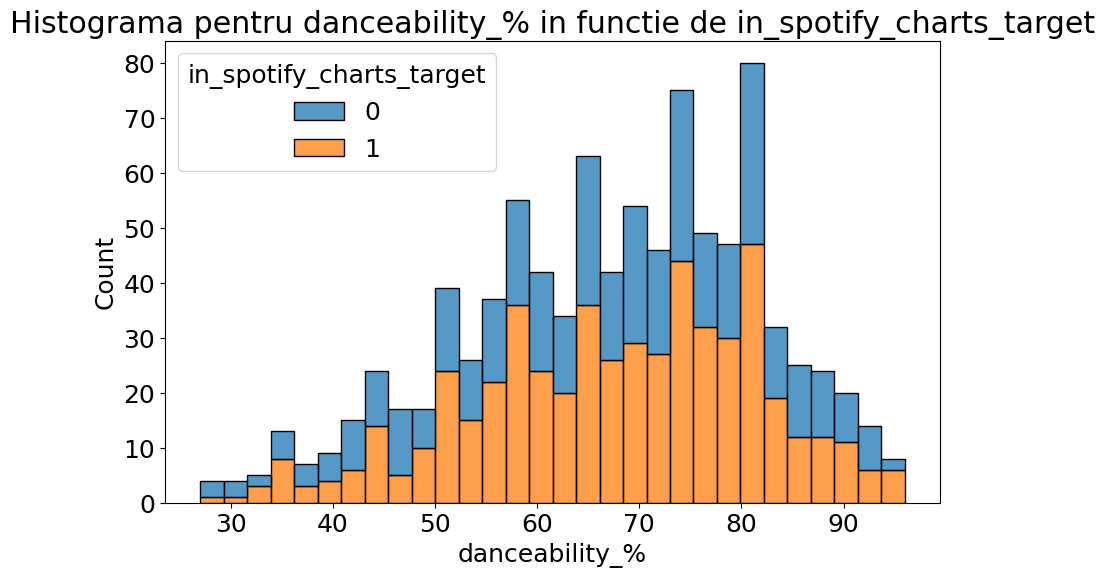

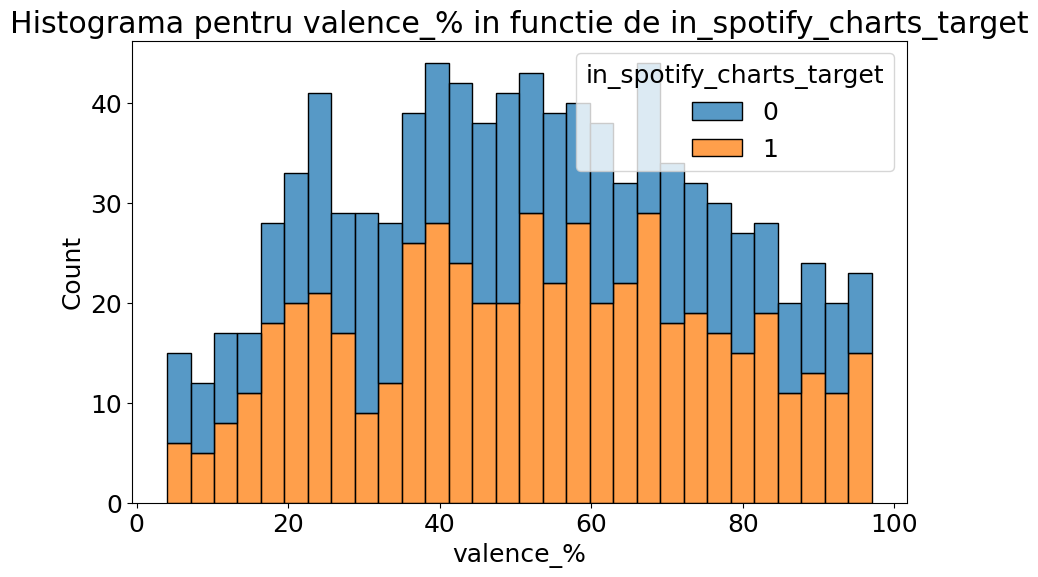

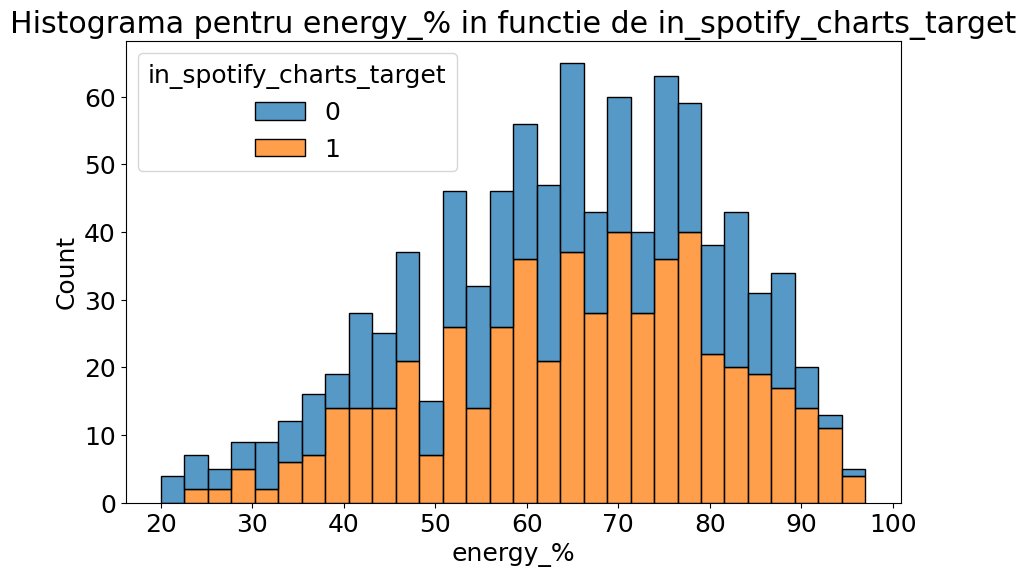

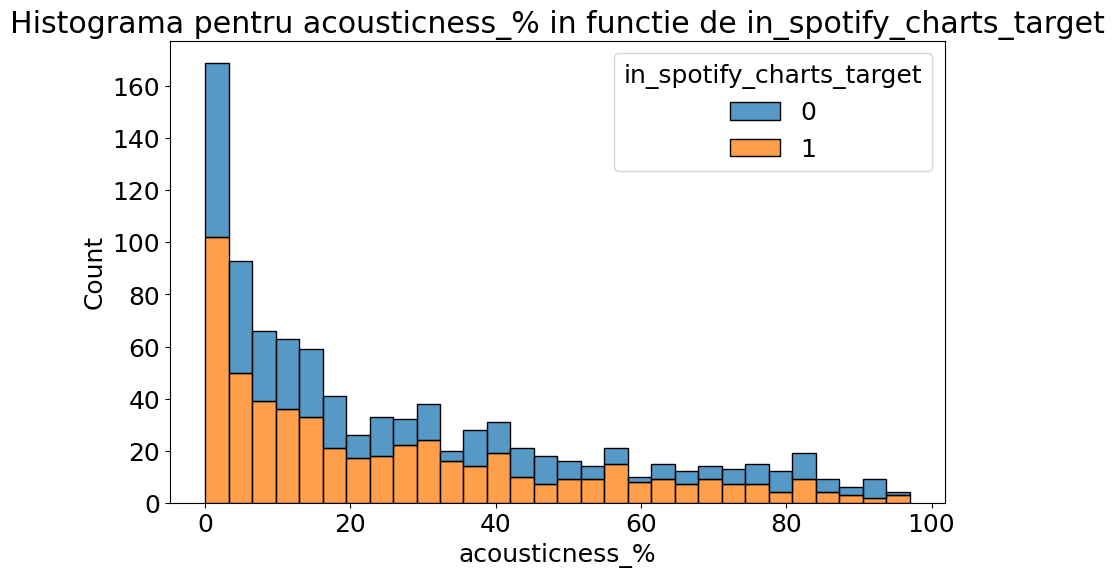

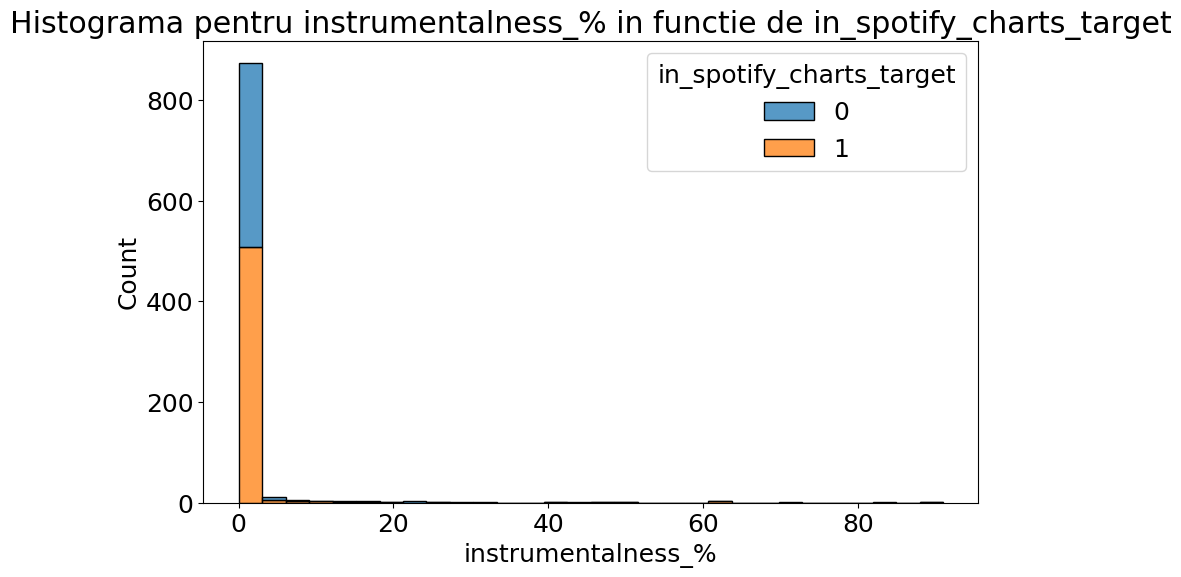

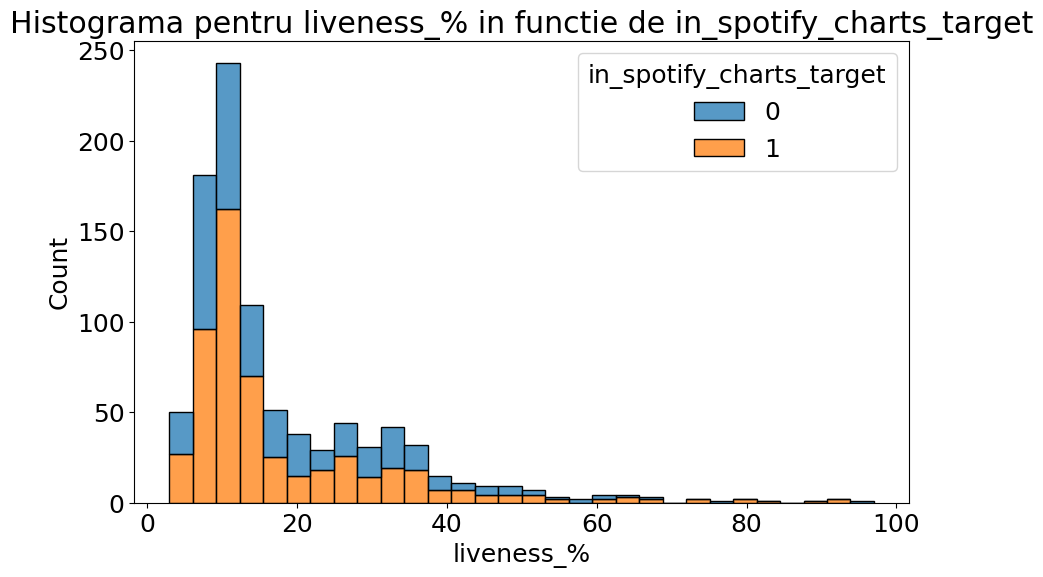

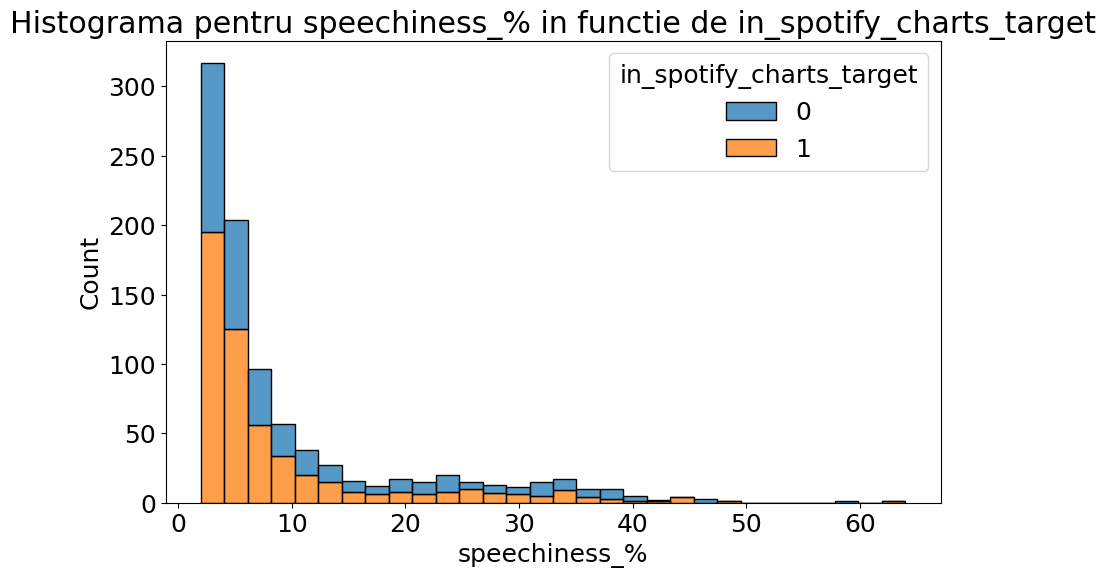

In [41]:
coloana_tinta = "in_spotify_charts_target"
for column in df.columns:
    if column != coloana_tinta and column not in ["track_name", "artist(s)_name"]:
        plt.figure(figsize=(10, 6))
        sns.histplot(data=df, x=column, hue=coloana_tinta, multiple="stack", bins=30)
        plt.title(f'Histograma pentru {column} in functie de {coloana_tinta}')
        plt.show()

# II. Modelare clasificatori

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 927 entries, 0 to 926
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   track_name                927 non-null    object
 1   artist(s)_name            927 non-null    object
 2   artist_count              927 non-null    int64 
 3   released_year             927 non-null    int64 
 4   released_month            927 non-null    int64 
 5   released_day              927 non-null    int64 
 6   in_spotify_playlists      927 non-null    int64 
 7   in_spotify_charts         927 non-null    int64 
 8   streams                   927 non-null    int64 
 9   in_apple_playlists        927 non-null    int64 
 10  in_apple_charts           927 non-null    int64 
 11  in_deezer_playlists       927 non-null    int64 
 12  in_deezer_charts          927 non-null    int64 
 13  in_shazam_charts          927 non-null    int64 
 14  bpm                       

In [43]:
df = df.drop(['track_name', 'artist(s)_name'], axis=1)

label_encoder = LabelEncoder()
df['mode'] = label_encoder.fit_transform(df['mode'])

In [44]:
X = df.drop(['in_spotify_charts_target'], axis=1)
y = df['in_spotify_charts_target']

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify = y, random_state=9) 

In [46]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [47]:
def acuratetea_clasificatorului(model_clasificare, y_predicted):
    print('Matrice confuzie pe X_test cu ' + model_clasificare +' :\n')
    disp= met.ConfusionMatrixDisplay(met.confusion_matrix(y_test, y_predicted))
    disp.plot()
    plt.show()
    metrics  = met.precision_recall_fscore_support (y_test, y_predicted, average=None)
    print('Acuratete', round(met.accuracy_score(y_test, y_predicted),2)) 
    df_results = pd.DataFrame([ 
   
        {'metric':'Precision',
       'class 0':round(metrics[0][0],2),
       'class 1':round(metrics[0][1],2)},
     {'metric':'Recall', 
       'class 0':round(metrics[1][0],2),
       'class 1':round(metrics[1][1],2)},
     {'metric':'F1-score', 
       'class 0':round(metrics[2][0],2),
       'class 1':round(metrics[2][1],2)}])
    
    display(df_results)

### Regresie logistica

Matrice confuzie pe X_test cu Regresia logistica :



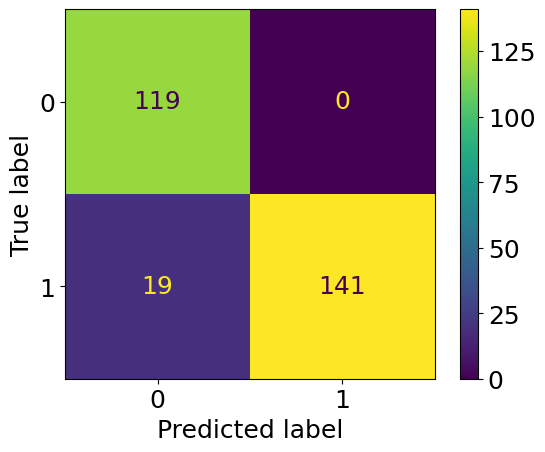

Acuratete 0.93


,metric,class 0,class 1
0,Precision,0.86,1.00
1,Recall,1.00,0.88
2,F1-score,0.93,0.94


In [48]:
regresia_logistica_clasificator = LogisticRegression(random_state = 9)
regresia_logistica_clasificator.fit(X_train, y_train)

y_pred_regresia_logistica = regresia_logistica_clasificator.predict(X_test)

acuratetea_clasificatorului('Regresia logistica', y_pred_regresia_logistica)

### KNN

Matrice confuzie pe X_test cu KNN :



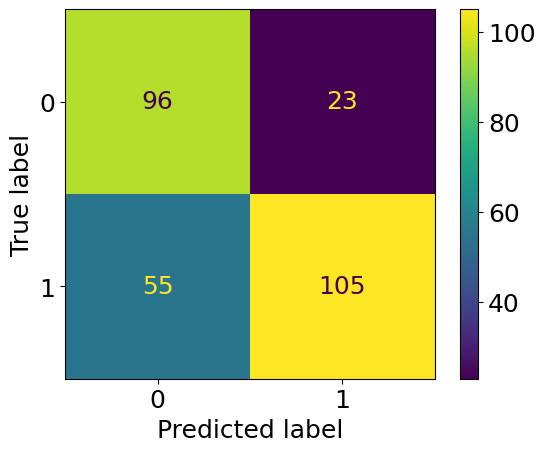

Acuratete 0.72


,metric,class 0,class 1
0,Precision,0.64,0.82
1,Recall,0.81,0.66
2,F1-score,0.71,0.73


In [49]:
knn_clasificator =KNeighborsClassifier(n_neighbors = 10)
knn_clasificator = knn_clasificator.fit(X_train, y_train)

y_pred_knn = knn_clasificator.predict(X_test)

acuratetea_clasificatorului('KNN', y_pred_knn)

### Arbore de clasificare

Matrice confuzie pe X_test cu Arbore de decizie :



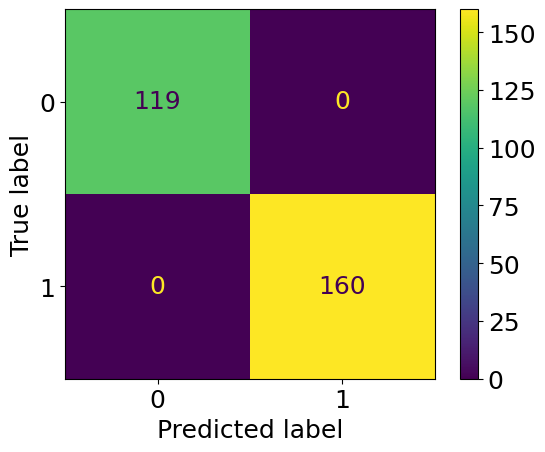

Acuratete 1.0


,metric,class 0,class 1
0,Precision,1.0,1.0
1,Recall,1.0,1.0
2,F1-score,1.0,1.0


In [50]:
arborde_decizie_clasificare = DecisionTreeClassifier(random_state = 9)
arborde_decizie_clasificare.fit(X_train, y_train)

y_pred_arbore_decizie = arborde_decizie_clasificare.predict(X_test)

acuratetea_clasificatorului('Arbore de decizie', y_pred_arbore_decizie)

### Padure aleatoare

Matrice confuzie pe X_test cu Padure aleatoare :



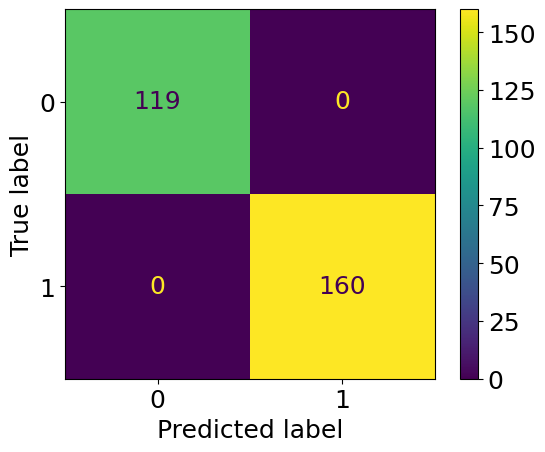

Acuratete 1.0


,metric,class 0,class 1
0,Precision,1.0,1.0
1,Recall,1.0,1.0
2,F1-score,1.0,1.0


In [51]:
padure_aleatoare_clasificare = RandomForestClassifier(n_estimators=200, max_samples= 0.3)
padure_aleatoare_clasificare.fit(X_train, y_train)

y_pred_padure_aleatoare = padure_aleatoare_clasificare.predict(X_test)

acuratetea_clasificatorului('Padure aleatoare', y_pred_padure_aleatoare)

### Optimizare

### Regresie logistica

Cei mai buni parametri pentru regresia logistica:  {'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
Cel mai bun estimator pentru regresia logistica:  LogisticRegression(C=100, random_state=9)
Matrice confuzie pe X_test cu Optimizare Regresie logistica :



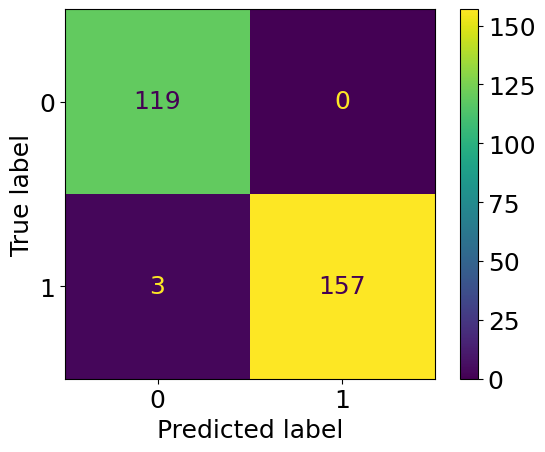

Acuratete 0.99


,metric,class 0,class 1
0,Precision,0.98,1.00
1,Recall,1.00,0.98
2,F1-score,0.99,0.99


In [52]:
parametri_grid_regresie_logistica = {
    'C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100], 
    'penalty': ['l2'], 
    'solver': ['lbfgs', 'liblinear']}

grid_search_regresie_logistica = GridSearchCV(LogisticRegression(random_state = 9), parametri_grid_regresie_logistica, cv=5, scoring='accuracy')
grid_search_regresie_logistica.fit(X_train, y_train)

best_params_regresie_logistica = grid_search_regresie_logistica.best_params_
best_estimator_regresie_logistica = grid_search_regresie_logistica.best_estimator_

print("Cei mai buni parametri pentru regresia logistica: ", best_params_regresie_logistica)
print("Cel mai bun estimator pentru regresia logistica: ", best_estimator_regresie_logistica)

y_pred_regresie_logistica_optimizata = best_estimator_regresie_logistica.predict(X_test)
acuratetea_clasificatorului('Optimizare Regresie logistica', y_pred_regresie_logistica_optimizata)

### KNN

Cei mai buni parametri pentru KNN:  {'metric': 'manhattan', 'n_neighbors': 14, 'weights': 'distance'}
Cel mai bun estimator pentru KNN:  KNeighborsClassifier(metric='manhattan', n_neighbors=14, weights='distance')
Matrice confuzie pe X_test cu Optimizare KNN :



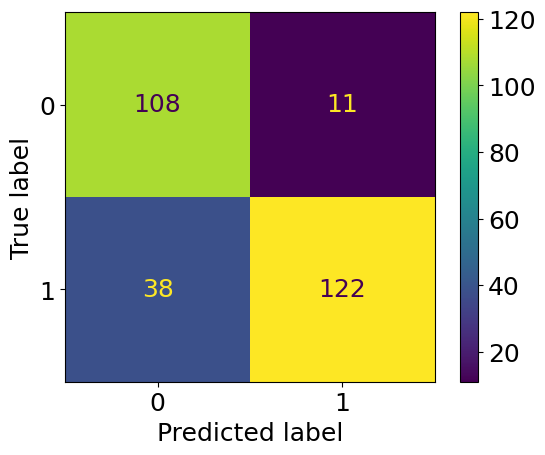

Acuratete 0.82


,metric,class 0,class 1
0,Precision,0.74,0.92
1,Recall,0.91,0.76
2,F1-score,0.82,0.83


In [53]:
parametri_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 14, 15, 16],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search_knn = GridSearchCV(KNeighborsClassifier(), parametri_grid_knn, cv=5, scoring='accuracy')
grid_search_knn.fit(X_train, y_train)

best_params_knn = grid_search_knn.best_params_
best_estimator_knn = grid_search_knn.best_estimator_

print("Cei mai buni parametri pentru KNN: ", best_params_knn)
print("Cel mai bun estimator pentru KNN: ", best_estimator_knn)

y_pred_knn_optimizata = best_estimator_knn.predict(X_test)
acuratetea_clasificatorului('Optimizare KNN', y_pred_knn_optimizata)

### Arbore de clasificare

Cei mai buni parametri pentru Arbore decizie:  {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Cel mai bun estimator pentru Arbore decizie:  DecisionTreeClassifier(random_state=9)
Matrice confuzie pe X_test cu Optimizare Arbore decizie :



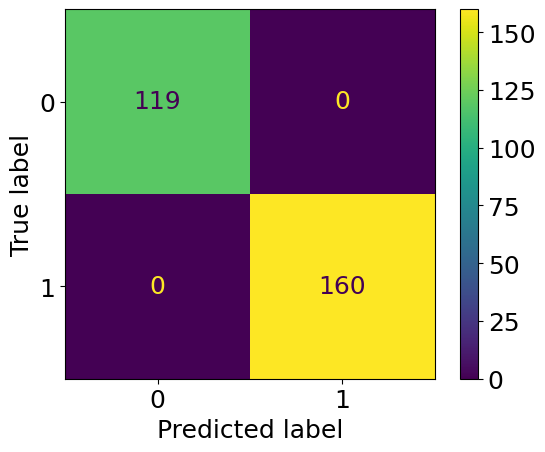

Acuratete 1.0


,metric,class 0,class 1
0,Precision,1.0,1.0
1,Recall,1.0,1.0
2,F1-score,1.0,1.0


In [54]:
param_grid_arbore_decizie = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search_arbore_decizie = GridSearchCV(DecisionTreeClassifier(random_state = 9), param_grid_arbore_decizie, cv=5, scoring='accuracy')
grid_search_arbore_decizie.fit(X_train, y_train)

best_params_arbore_decizie = grid_search_arbore_decizie.best_params_
best_estimator_arbore_decizie = grid_search_arbore_decizie.best_estimator_

print("Cei mai buni parametri pentru Arbore decizie: ", best_params_arbore_decizie)
print("Cel mai bun estimator pentru Arbore decizie: ", best_estimator_arbore_decizie)

y_pred_arbore_decizie_optimizata = best_estimator_arbore_decizie.predict(X_test)
acuratetea_clasificatorului('Optimizare Arbore decizie', y_pred_arbore_decizie_optimizata)

### Padure aleatoare

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Cei mai buni parametri pentru Padure aleatoare:  {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 10}
Cel mai bun estimator pentru Padure aleatoare  RandomForestClassifier(n_estimators=10, random_state=9)
Matrice confuzie pe X_test cu Optimizare Padure aleatoare :



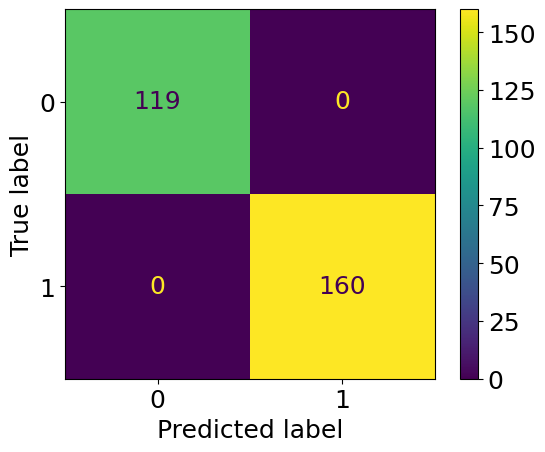

Acuratete 1.0


,metric,class 0,class 1
0,Precision,1.0,1.0
1,Recall,1.0,1.0
2,F1-score,1.0,1.0


In [55]:
param_grid_padure_aleatoare={
    'n_estimators':[10,20], 
    'max_depth':[None, 5], 
    'min_samples_split':[2,3]}

grid_search_padure_aleatoare = GridSearchCV(RandomForestClassifier(random_state = 9), param_grid_padure_aleatoare, cv=5, n_jobs=-1, verbose=1)
grid_search_padure_aleatoare.fit(X_train, y_train)

best_params_padure_aleatoare = grid_search_padure_aleatoare.best_params_
best_estimator_padure_aleatoare = grid_search_padure_aleatoare.best_estimator_

print("Cei mai buni parametri pentru Padure aleatoare: ", best_params_padure_aleatoare)
print("Cel mai bun estimator pentru Padure aleatoare ", best_estimator_padure_aleatoare)

y_pred_padure_aleatoare_optimizata = best_estimator_padure_aleatoare.predict(X_test)
acuratetea_clasificatorului('Optimizare Padure aleatoare', y_pred_padure_aleatoare_optimizata)